# EDA — Augmented BioCatch Dataset (~1M sessions)

**Anti-Vishing Initiative:** Exploratory Analysis of the Augmented Synthetic Dataset

## Objective

Exploratory analysis of the synthetically augmented dataset built from the original dataset analyzed in `1_EDA.ipynb`. The analysis aims to:

1. **Validate the integrity of the augmented dataset** — nulls, types, ranges, expected duplicates
2. **Characterize the change in class balance** relative to the original dataset
3. **Confirm that discriminative signals were preserved** after augmentation
4. **Compare distributions** of the augmented dataset vs the original dataset (KS test)
5. **Generate recommendations** for the modeling strategy with augmented data

**Dataset:** `augmented_data/dataset_1M_vishing_.parquet` — ~1M sessions, 54 features

**Reference:** `raw_data/biocatch_sinthetic_data.csv` — 50K original sessions

## 1. Setup and Data Loading

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency, pointbiserialr, ks_2samp
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {'legit': '#2ecc71', 'vishing': '#e74c3c', 'neutral': '#3498db', 'aug': '#9b59b6'}
LABEL_MAP = {0: 'Legitimate', 1: 'Vishing'}

print('Libraries loaded')

Libraries loaded


In [19]:
# Load augmented dataset
df = pd.read_parquet("data_augmentation\dataset_1M_vishing_ctgan.parquet")

df_original = pd.read_csv('raw_data/biocatch_sinthetic_data.csv')

# session_timestamp comes as object in the parquet
df['session_timestamp'] = pd.to_datetime(df['session_timestamp'])

df_legit = df[df['is_vishing'] == 0]
df_vishing = df[df['is_vishing'] == 1]
imbalance = len(df_legit) // len(df_vishing)

print(f'Augmented dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Legitimate sessions: {len(df_legit):,} ({len(df_legit)/len(df)*100:.2f}%)')
print(f'Vishing sessions:    {len(df_vishing):,} ({len(df_vishing)/len(df)*100:.2f}%)')
print(f'Imbalance ratio: 1:{imbalance}')
print()
print('Comparison with original dataset:')
print(f'  Original:  50,000 rows | 95.0% legit | 5.0% vishing | ratio 1:19')
print(f'  Augmented: {df.shape[0]:,} rows | {len(df_legit)/len(df)*100:.1f}% legit | {len(df_vishing)/len(df)*100:.1f}% vishing | ratio 1:{imbalance}')

Augmented dataset: 1,000,000 rows x 62 columns
Legitimate sessions: 985,000 (98.50%)
Vishing sessions:    15,000 (1.50%)
Imbalance ratio: 1:65

Comparison with original dataset:
  Original:  50,000 rows | 95.0% legit | 5.0% vishing | ratio 1:19
  Augmented: 1,000,000 rows | 98.5% legit | 1.5% vishing | ratio 1:65


## 2. Augmented Dataset Quality Validation

Duplicated `session_id` values are **expected** — augmentation generates synthetic sessions derived from original sessions that share the same base ID.

In [21]:
# 2.1 Types, nulls, duplicates
print('='*60)
print('DATA TYPES')
print('='*60)
for dtype, count in df.dtypes.value_counts().items():
    print(f'  {dtype}: {count} columns')

print()
print('NULL VALUES')
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print('  Zero null values')
else:
    print(null_counts[null_counts > 0])

print()
print('DUPLICATES')
print(f'  Duplicated Session IDs: {df["session_id"].duplicated().sum():,} (expected in augmented data)')
print(f'  Fully duplicated rows: {df.duplicated().sum():,}')

print()
print('CUSTOMERS AND SESSIONS')
print(f'  Unique customers: {df["customer_id"].nunique():,}')
spc = df.groupby('customer_id').size()
print(f'  Sessions/customer (average): {spc.mean():.1f}')
print(f'  Time range: {df["session_timestamp"].min()} -> {df["session_timestamp"].max()}')

DATA TYPES
  int64: 29 columns
  float64: 26 columns
  object: 6 columns
  datetime64[ns]: 1 columns

NULL VALUES
  Zero null values

DUPLICATES
  Duplicated Session IDs: 0 (expected in augmented data)
  Fully duplicated rows: 0

CUSTOMERS AND SESSIONS
  Unique customers: 89,999
  Sessions/customer (average): 11.1
  Time range: 2024-06-01 00:00:05 -> 2025-05-31 23:58:36


In [22]:
# 2.2 Columns present vs original dataset
base_cols = df.columns.tolist()
orig_only = df_original.columns.to_list()
aug_only = set(base_cols) - set(orig_only)
orig_only = set(orig_only) - set(base_cols)

print('COLUMN COMPARISON vs ORIGINAL DATASET')
print(f'  Only in augmented ({len(aug_only)}): {sorted(aug_only)}')
print(f'  Only in original  ({len(orig_only)}): {sorted(orig_only)}')

COLUMN COMPARISON vs ORIGINAL DATASET
  Only in augmented (1): ['is_synthetic']
  Only in original  (0): []


FEATURE: is_synthetic

Global distribution:
                    count  percentage
Non-synthetic (0)   42579        4.26
Synthetic (1)      957421       95.74

Contingency table with is_vishing:
                   Legitimate (0)  Vishing (1)
Non-synthetic (0)           40452         2127
Synthetic (1)              944548        12873

Proportions by sample type:
                   Legitimate (%)  Vishing (%)
Non-synthetic (0)           95.00         5.00
Synthetic (1)               98.66         1.34

Association test:
  Chi2 = 3675.1238
  p-value = 0
  Odds Ratio = 0.2592


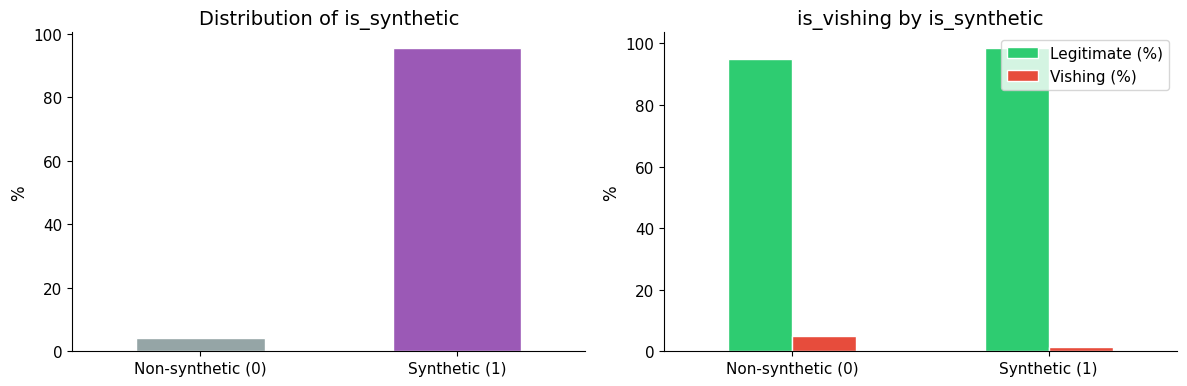

In [23]:
# Short statistical analysis of is_synthetic

print("FEATURE: is_synthetic")
print("=" * 60)

synthetic_counts = df["is_synthetic"].value_counts().sort_index()
synthetic_pct = df["is_synthetic"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    "count": synthetic_counts,
    "percentage": synthetic_pct.round(2)
})
summary.index = ["Non-synthetic (0)", "Synthetic (1)"]

print("\nGlobal distribution:")
print(summary.to_string())

# Relationship with the target class
ct = pd.crosstab(df["is_synthetic"], df["is_vishing"])
ct.index = ["Non-synthetic (0)", "Synthetic (1)"]
ct.columns = ["Legitimate (0)", "Vishing (1)"]

print("\nContingency table with is_vishing:")
print(ct.to_string())

# Row-wise proportions
row_pct = pd.crosstab(df["is_synthetic"], df["is_vishing"], normalize="index") * 100
row_pct.index = ["Non-synthetic (0)", "Synthetic (1)"]
row_pct.columns = ["Legitimate (%)", "Vishing (%)"]

print("\nProportions by sample type:")
print(row_pct.round(2).to_string())

# Chi-square test and odds ratio
chi2_stat, p_val, dof, expected = chi2_contingency(pd.crosstab(df["is_synthetic"], df["is_vishing"]))

a = ct.loc["Synthetic (1)", "Vishing (1)"]
b = ct.loc["Synthetic (1)", "Legitimate (0)"]
c = ct.loc["Non-synthetic (0)", "Vishing (1)"]
d = ct.loc["Non-synthetic (0)", "Legitimate (0)"]
odds_ratio = (a * d) / (b * c) if (b * c) > 0 else np.inf

print("\nAssociation test:")
print(f"  Chi2 = {chi2_stat:.4f}")
print(f"  p-value = {p_val:.4g}")
print(f"  Odds Ratio = {odds_ratio:.4f}")

# Simple visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

summary["percentage"].plot(kind="bar", ax=axes[0], color=["#95a5a6", "#9b59b6"], edgecolor="white")
axes[0].set_title("Distribution of is_synthetic")
axes[0].set_ylabel("%")
axes[0].set_xticklabels(summary.index, rotation=0)

row_pct.plot(kind="bar", ax=axes[1], color=["#2ecc71", "#e74c3c"], edgecolor="white")
axes[1].set_title("is_vishing by is_synthetic")
axes[1].set_ylabel("%")
axes[1].set_xticklabels(row_pct.index, rotation=0)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

In [24]:
# 2.3 Range validation
range_checks = {
    'avg_touch_pressure': (0, 1), 'segmented_typing_ratio': (0, 1),
    'dead_time_ratio': (0, 1), 'data_familiarity_score': (0, 1),
    'keystroke_variability': (0, 1), 'hour_of_day': (0, 23),
    'device_tilt_angle_mean': (0, 90), 'is_vishing': (0, 1),
    'phone_call_active': (0, 1), 'errors_per_minute': (0, None), 'interactions_per_s': (0, None),
}

print('RANGE VALIDATION')
all_ok = True
for col, (lo, hi) in range_checks.items():
    actual_min, actual_max = float(df[col].min()), float(df[col].max())
    ok = actual_min >= lo and (hi is None or actual_max <= hi)
    status = 'OK  ' if ok else 'FAIL'
    if not ok:
        all_ok = False
    print(f'  [{status}] {col}: [{actual_min:.3f}, {actual_max:.3f}]')
if all_ok:
    print('  All ranges valid')

RANGE VALIDATION
  [OK  ] avg_touch_pressure: [0.097, 0.912]
  [OK  ] segmented_typing_ratio: [0.000, 0.753]
  [OK  ] dead_time_ratio: [0.000, 0.489]
  [OK  ] data_familiarity_score: [0.054, 1.000]
  [OK  ] keystroke_variability: [0.010, 0.658]
  [OK  ] hour_of_day: [0.000, 23.000]
  [OK  ] device_tilt_angle_mean: [4.100, 83.699]
  [OK  ] is_vishing: [0.000, 1.000]
  [OK  ] phone_call_active: [0.000, 1.000]
  [OK  ] errors_per_minute: [0.000, 600.000]
  [OK  ] interactions_per_s: [1.000, 31.000]
  All ranges valid


In [25]:
# 2.4 Descriptive statistics
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'is_vishing']

desc = df[numeric_cols].describe().T
desc['skew'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
print(f'Statistics of {len(numeric_cols)} numeric features:')
desc[['count','mean','std','min','25%','50%','75%','max','skew','kurtosis']].round(3)

Statistics of 54 numeric features:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
avg_keyhold_ms,1000000.0,95.378,22.213,21.500,78.800,95.900,111.100,1.896000e+02,0.037,-0.566
avg_interkey_latency_ms,1000000.0,162.462,46.319,30.000,127.000,155.300,196.500,4.146000e+02,0.437,-0.213
typing_speed_cps,1000000.0,4.674,1.126,0.500,3.989,4.756,5.323,1.007000e+01,0.044,0.208
keystroke_variability,1000000.0,0.220,0.068,0.010,0.177,0.207,0.259,6.580000e-01,0.789,1.457
segmented_typing_ratio,1000000.0,0.191,0.109,0.000,0.109,0.160,0.242,7.530000e-01,1.099,0.726
avg_touch_pressure,1000000.0,0.491,0.105,0.097,0.406,0.484,0.576,9.120000e-01,0.145,-0.654
avg_touch_size_px,1000000.0,41.850,7.091,11.600,38.496,42.528,45.736,7.570000e+01,-0.304,0.573
swipe_speed_px_s,1000000.0,706.765,166.727,113.300,597.300,724.800,822.900,1.415500e+03,-0.183,-0.469
swipe_directional_variance,1000000.0,0.170,0.065,0.000,0.122,0.169,0.212,5.080000e-01,0.403,0.250
scroll_speed_avg,1000000.0,516.762,124.934,66.799,430.266,509.346,598.759,1.067802e+03,0.221,-0.410


## 3. Target Distribution and Categorical Variables

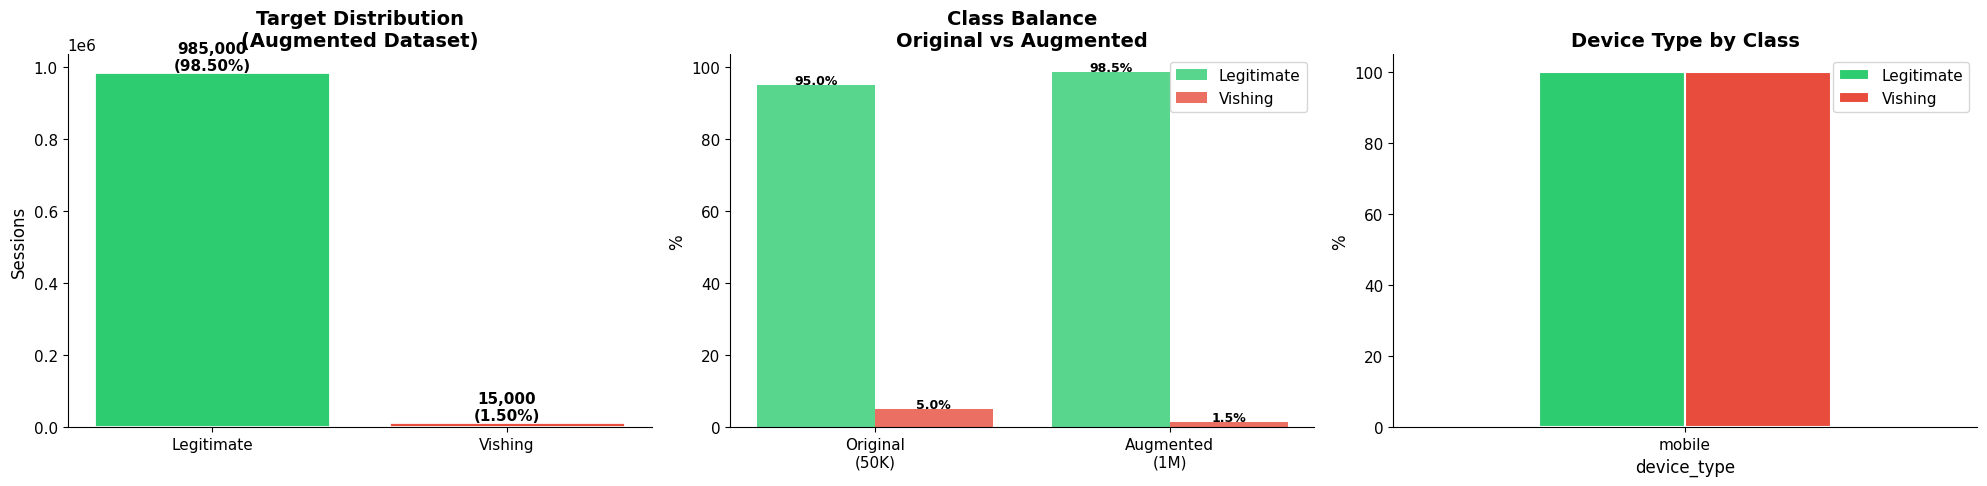

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 3.1 Target
counts = df['is_vishing'].value_counts().sort_index()
bars = axes[0].bar(['Legitimate', 'Vishing'], counts.values,
                    color=[COLORS['legit'], COLORS['vishing']], edgecolor='white', linewidth=2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{val:,}\n({val/len(df)*100:.2f}%)', ha='center', fontweight='bold')
axes[0].set_title('Target Distribution\n(Augmented Dataset)', fontweight='bold')
axes[0].set_ylabel('Sessions')

# 3.2 Balance comparison
aug_pcts = [len(df_legit)/len(df)*100, len(df_vishing)/len(df)*100]
orig_pcts = [95.0, 5.0]
x = np.arange(2)
b1 = axes[1].bar(x - 0.2, [orig_pcts[0], aug_pcts[0]], 0.4, label='Legitimate',
                  color=COLORS['legit'], alpha=0.8)
b2 = axes[1].bar(x + 0.2, [orig_pcts[1], aug_pcts[1]], 0.4, label='Vishing',
                  color=COLORS['vishing'], alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Original\n(50K)', 'Augmented\n(1M)'])
axes[1].set_title('Class Balance\nOriginal vs Augmented', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend()
for rect in list(b1) + list(b2):
    axes[1].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.3,
                 f'{rect.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# 3.3 Device type
ct = pd.crosstab(df['device_type'], df['is_vishing'], normalize='columns') * 100
ct.plot(kind='bar', ax=axes[2], color=[COLORS['legit'], COLORS['vishing']],
        edgecolor='white', linewidth=1.5)
axes[2].set_title('Device Type by Class', fontweight='bold')
axes[2].set_ylabel('%')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(['Legitimate', 'Vishing'])

plt.tight_layout()
plt.show()

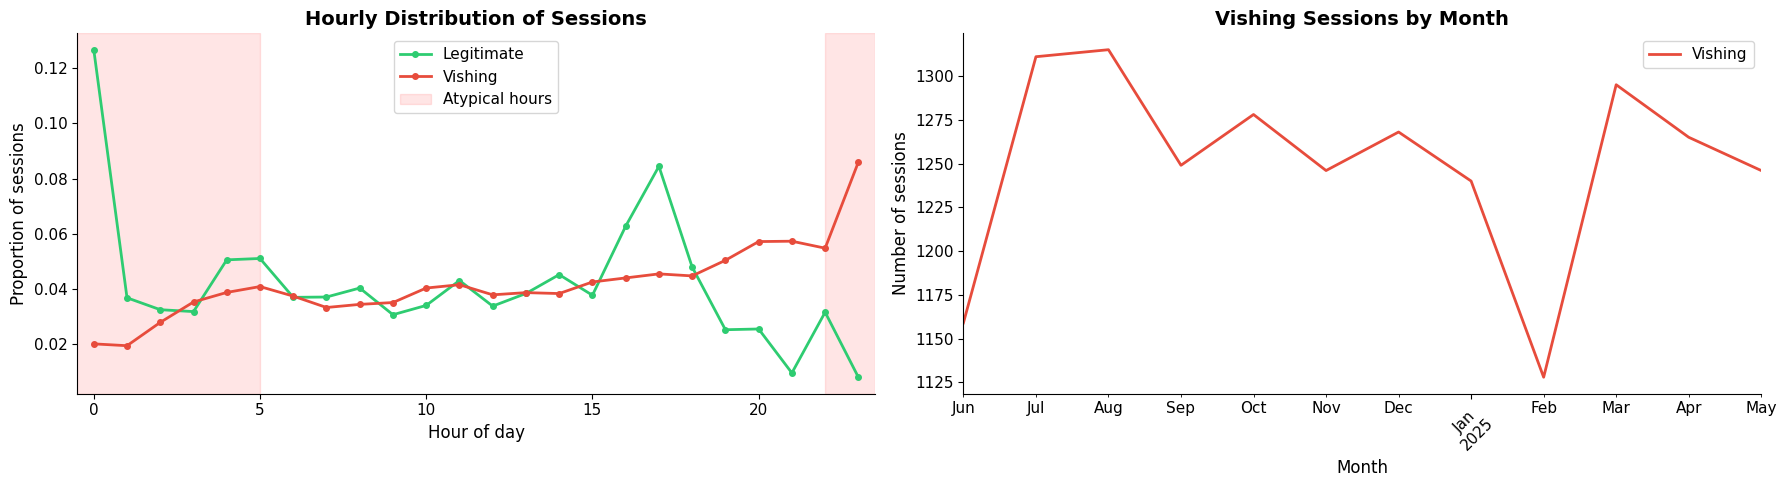

In [9]:
# 3.4 Temporal distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for label, subset, color in [(0, df_legit, COLORS['legit']), (1, df_vishing, COLORS['vishing'])]:
    hour_dist = subset['hour_of_day'].value_counts().sort_index()
    hour_dist = hour_dist / hour_dist.sum()
    axes[0].plot(hour_dist.index, hour_dist.values, '-o', color=color,
                 label=LABEL_MAP[label], linewidth=2, markersize=4)
axes[0].axvspan(22, 23.5, alpha=0.1, color='red', label='Atypical hours')
axes[0].axvspan(-0.5, 5, alpha=0.1, color='red')
axes[0].set_title('Hourly Distribution of Sessions', fontweight='bold')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Proportion of sessions')
axes[0].legend()
axes[0].set_xlim(-0.5, 23.5)

df['month'] = df['session_timestamp'].dt.to_period('M')
monthly = df.groupby(['month', 'is_vishing']).size().unstack(fill_value=0)
if 1 in monthly.columns:
    monthly[1].plot(ax=axes[1], color=COLORS['vishing'], linewidth=2, label='Vishing')
axes[1].set_title('Vishing Sessions by Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of sessions')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
df.drop(columns='month', inplace=True)

plt.tight_layout()
plt.show()

## 4. Univariate Analysis — Feature Distribution by Class

With 1M sessions the estimation noise is minimal. A subsample of 50K legitimate sessions is used for visualization.

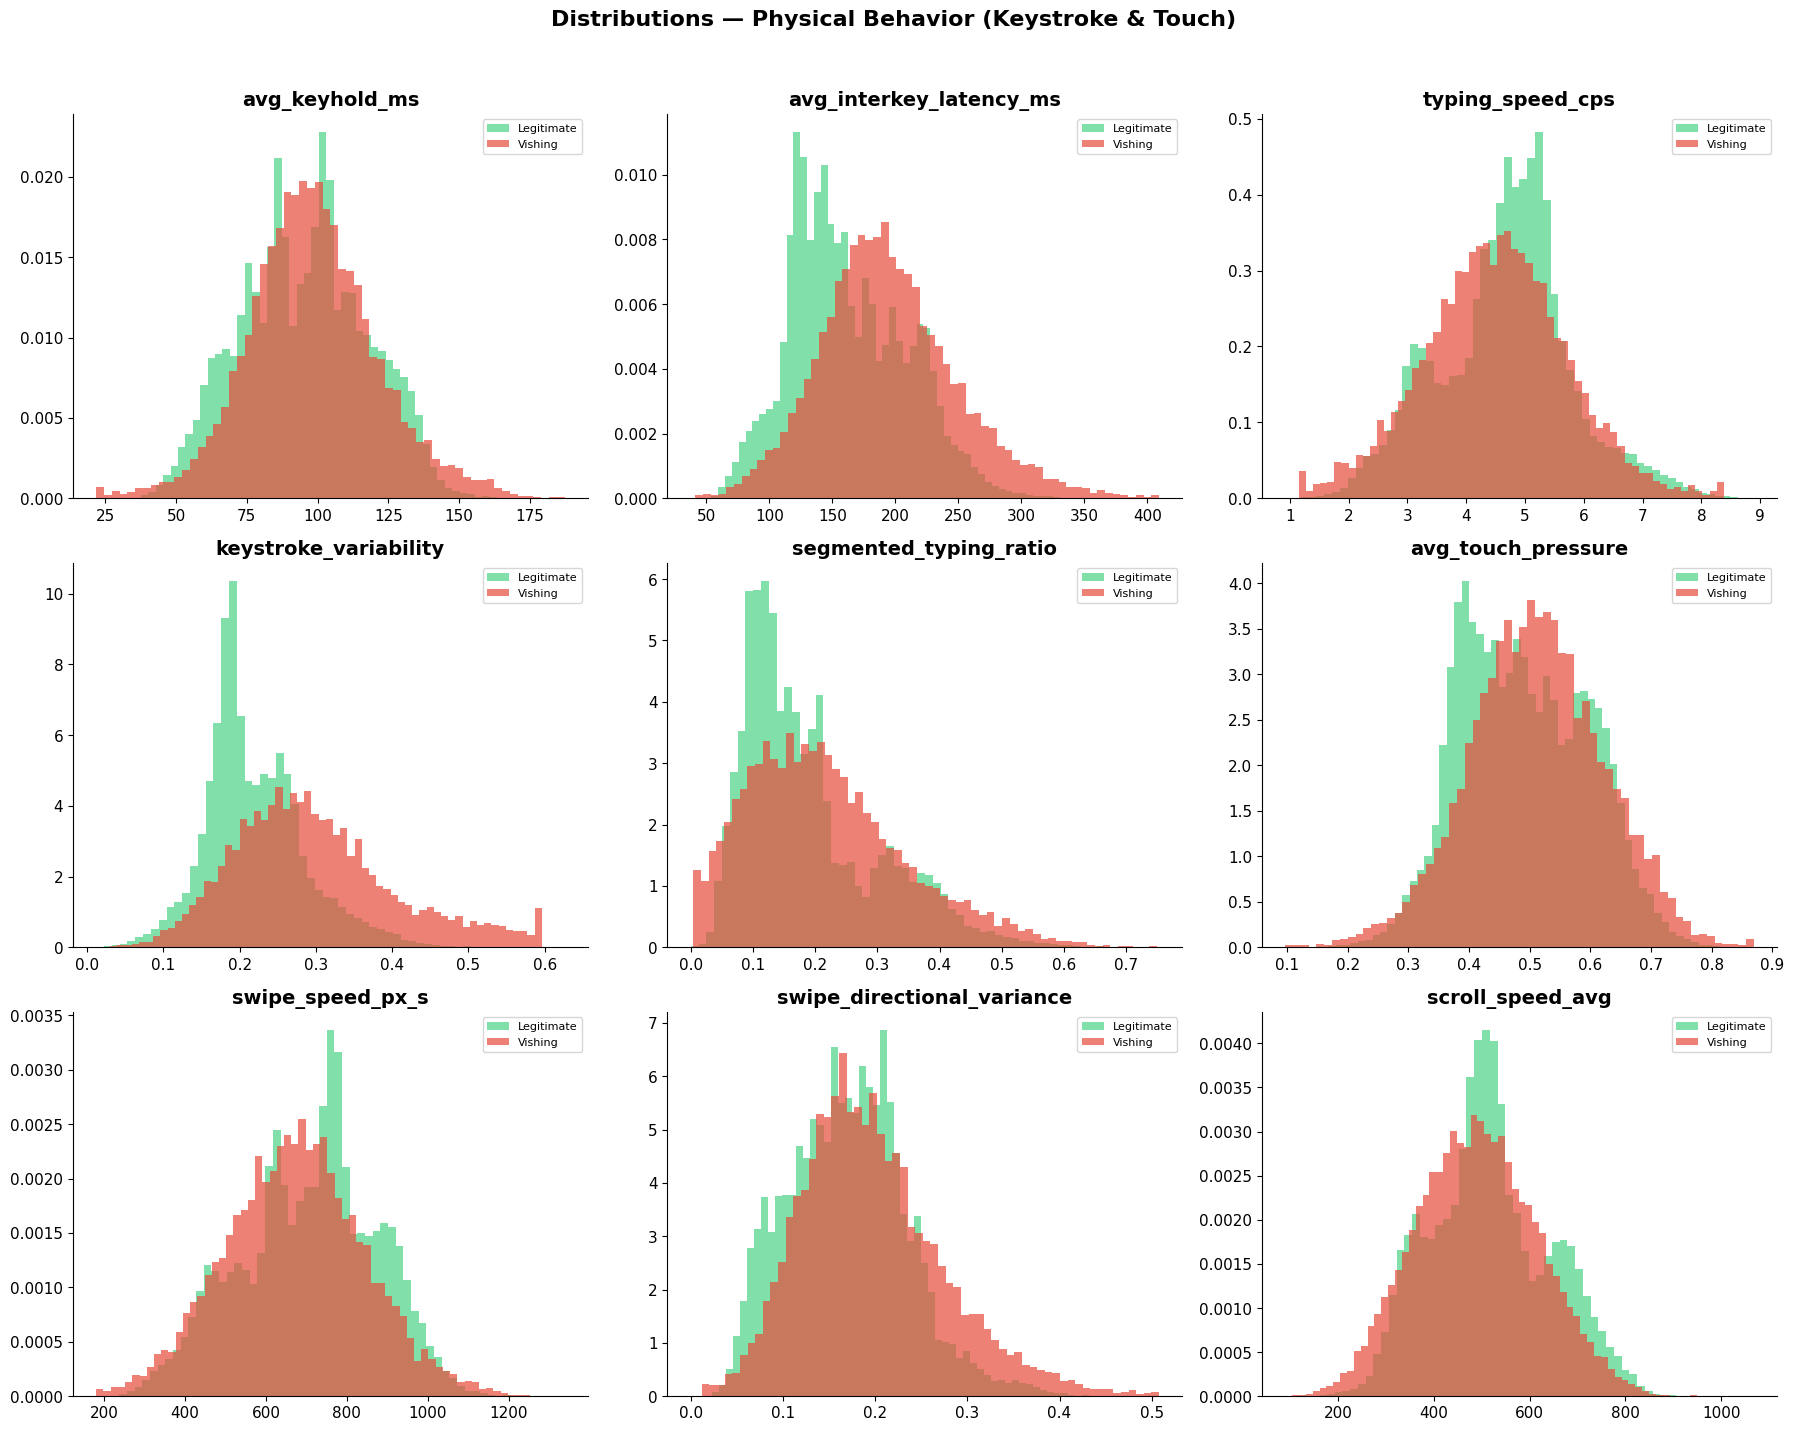

In [27]:
# 4.1 Physical behavior — keystroke & touch
physical_features = [
    'avg_keyhold_ms', 'avg_interkey_latency_ms', 'typing_speed_cps',
    'keystroke_variability', 'segmented_typing_ratio', 'avg_touch_pressure',
    'swipe_speed_px_s', 'swipe_directional_variance', "scroll_speed_avg"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()
for i, feat in enumerate(physical_features):
    ax = axes[i]
    ax.hist(df_legit[feat].sample(50000, random_state=42), bins=60, alpha=0.6,
            color=COLORS['legit'], label='Legitimate', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=60, alpha=0.7, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
fig.suptitle('Distributions — Physical Behavior (Keystroke & Touch)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

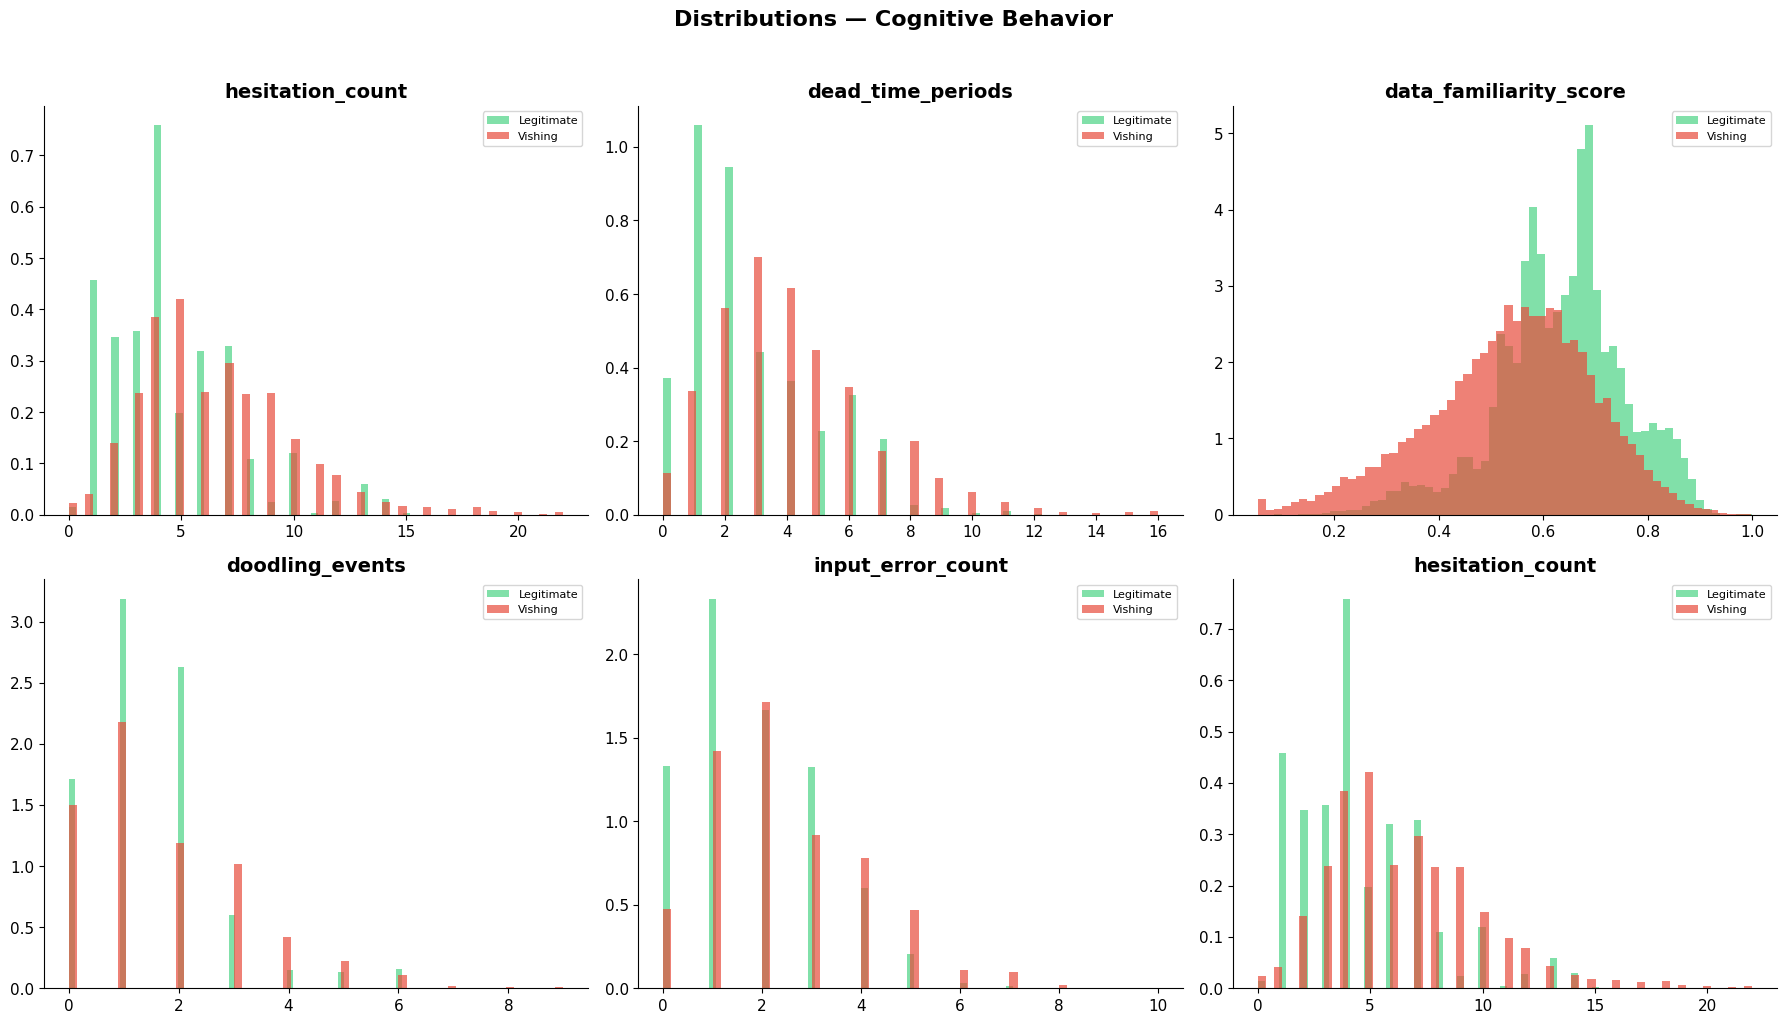

In [28]:
# 4.2 Cognitive behavior
cognitive_features = [
    'hesitation_count', 'dead_time_periods', 'data_familiarity_score',
    'doodling_events', 'input_error_count', 'hesitation_count'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for i, feat in enumerate(cognitive_features):
    ax = axes[i]
    ax.hist(df_legit[feat].sample(50000, random_state=42), bins=60, alpha=0.6,
            color=COLORS['legit'], label='Legitimate', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=60, alpha=0.7, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
fig.suptitle('Distributions — Cognitive Behavior',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

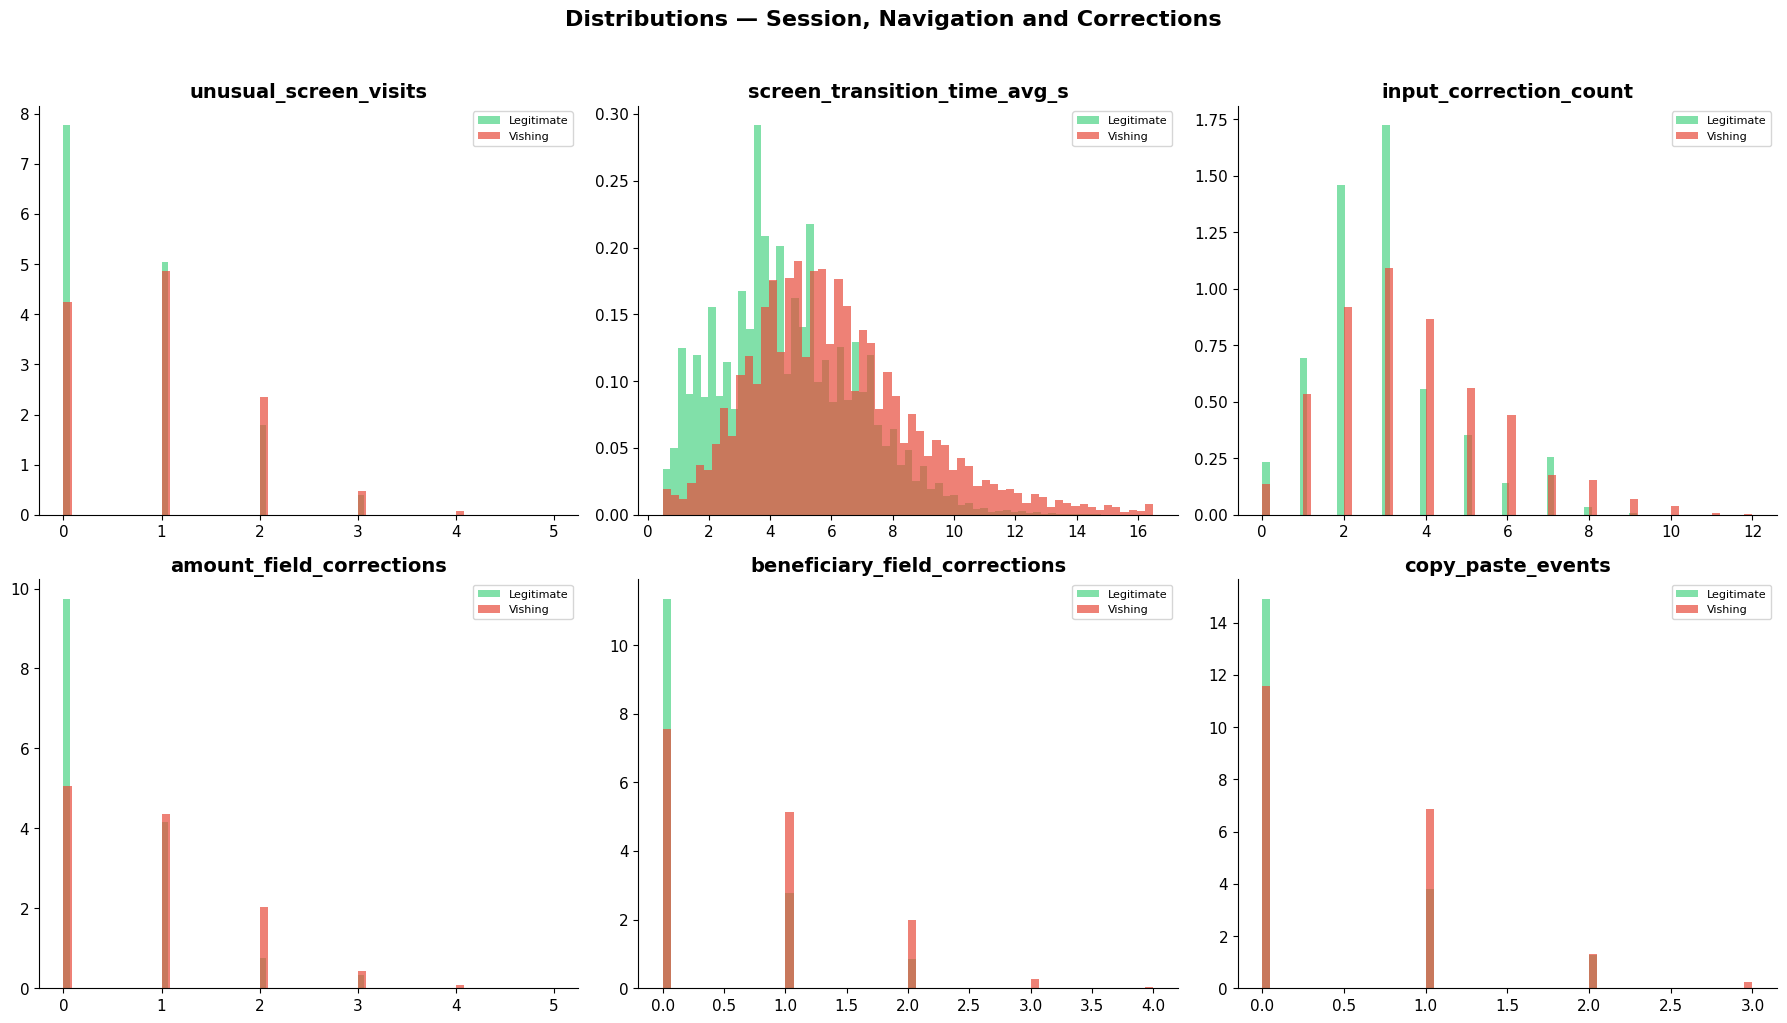

In [30]:
# 4.3 Session, navigation and corrections
session_features = [
    'unusual_screen_visits',
    'screen_transition_time_avg_s',
    'input_correction_count', 'amount_field_corrections',
    'beneficiary_field_corrections', 'copy_paste_events'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for i, feat in enumerate(session_features):
    ax = axes[i]
    ax.hist(df_legit[feat].sample(50000, random_state=42), bins=60, alpha=0.6,
            color=COLORS['legit'], label='Legitimate', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=60, alpha=0.7, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
fig.suptitle('Distributions — Session, Navigation and Corrections',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Statistical Separability Tests

With 1M sessions practically everything will have p→0. **Cohen's d** and the **univariate AUC** are the informative metrics. A subsample of 100K legitimate + all vishing is used for the computations.

In [31]:
from sklearn.metrics import roc_auc_score

features_to_test = [c for c in numeric_cols if c != 'is_vishing']

df_sample = pd.concat([
    df_legit.sample(100_000, random_state=42),
    df_vishing
]).reset_index(drop=True)
df_s_legit = df_sample[df_sample['is_vishing'] == 0]
df_s_vishing = df_sample[df_sample['is_vishing'] == 1]

results = []
for feat in features_to_test:
    x0 = df_s_legit[feat].dropna()
    x1 = df_s_vishing[feat].dropna()
    u_stat, p_val = mannwhitneyu(x0, x1, alternative='two-sided')
    pooled_std = np.sqrt((x0.std()**2 + x1.std()**2) / 2)
    cohens_d = (x1.mean() - x0.mean()) / pooled_std if pooled_std > 0 else 0
    r_pb, _ = pointbiserialr(df_sample['is_vishing'], df_sample[feat])
    try:
        auc = roc_auc_score(df_sample['is_vishing'], df_sample[feat])
        auc = max(auc, 1 - auc)
    except:
        auc = 0.5
    results.append({
        'feature': feat, 'mean_legit': x0.mean(), 'mean_vishing': x1.mean(),
        'pct_change': ((x1.mean()-x0.mean())/x0.mean()*100) if x0.mean() != 0 else np.inf,
        'cohens_d': cohens_d, 'abs_cohens_d': abs(cohens_d),
        'mann_whitney_p': p_val, 'point_biserial_r': r_pb, 'auc_univariate': auc,
    })

df_stats = pd.DataFrame(results).sort_values('abs_cohens_d', ascending=False)

def classify_effect(d):
    d = abs(d)
    if d >= 1.2: return 'Very large (>=1.2)'
    elif d >= 0.8: return 'Large (>=0.8)'
    elif d >= 0.5: return 'Medium (>=0.5)'
    elif d >= 0.2: return 'Small (>=0.2)'
    else: return 'Negligible (<0.2)'

df_stats['effect_size'] = df_stats['cohens_d'].apply(classify_effect)
df_stats['significant'] = df_stats['mann_whitney_p'] < 0.001

print(f'Features evaluated: {len(df_stats)} (sample: {len(df_sample):,} rows)')
print('Effect size distribution:')
print(df_stats['effect_size'].value_counts().to_string())
print(f'Significant (p<0.001): {df_stats["significant"].sum()} of {len(df_stats)}')

Features evaluated: 54 (sample: 115,000 rows)
Effect size distribution:
effect_size
Small (>=0.2)         23
Negligible (<0.2)     17
Medium (>=0.5)        10
Large (>=0.8)          3
Very large (>=1.2)     1
Significant (p<0.001): 52 of 54


In [32]:
# Table Top 30 by |Cohen's d|
display_cols = ['feature','mean_legit','mean_vishing','pct_change','cohens_d','effect_size','auc_univariate','point_biserial_r']
(
    df_stats[display_cols].head(30)
    .style
    .format({'mean_legit':'{:.3f}','mean_vishing':'{:.3f}','pct_change':'{:+.1f}%',
             'cohens_d':'{:+.3f}','auc_univariate':'{:.4f}','point_biserial_r':'{:+.4f}'})
    .bar(subset=['auc_univariate'], color='#3498db', vmin=0.5, vmax=1.0)
)

,feature,mean_legit,mean_vishing,pct_change,cohens_d,effect_size,auc_univariate,point_biserial_r
53,days_to_claim,-1.000,2.854,-385.4%,+2.035,Very large (>=1.2),1.0000,+0.8018
12,gyro_rotation_rate_mean,1.090,1.522,+39.7%,+0.910,Large (>=0.8),0.7415,+0.3482
3,keystroke_variability,0.219,0.298,+36.0%,+0.890,Large (>=0.8),0.7350,+0.3442
38,biocatch_risk_score,270.121,418.661,+55.0%,+0.840,Large (>=0.8),0.7191,+0.3048
19,data_familiarity_score,0.634,0.539,-15.0%,-0.672,Medium (>=0.5),0.6815,-0.2412
1,avg_interkey_latency_ms,162.007,194.452,+20.0%,+0.645,Medium (>=0.5),0.6767,+0.2253
24,hesitation_count,4.552,6.592,+44.8%,+0.642,Medium (>=0.5),0.6861,+0.2257
25,dead_time_periods,2.701,4.210,+55.9%,+0.635,Medium (>=0.5),0.6825,+0.2259
52,hesitation_composite,4.498,6.507,+44.7%,+0.627,Medium (>=0.5),0.6814,+0.2216
18,screen_transition_time_avg_s,4.608,6.075,+31.8%,+0.588,Medium (>=0.5),0.6572,+0.2091


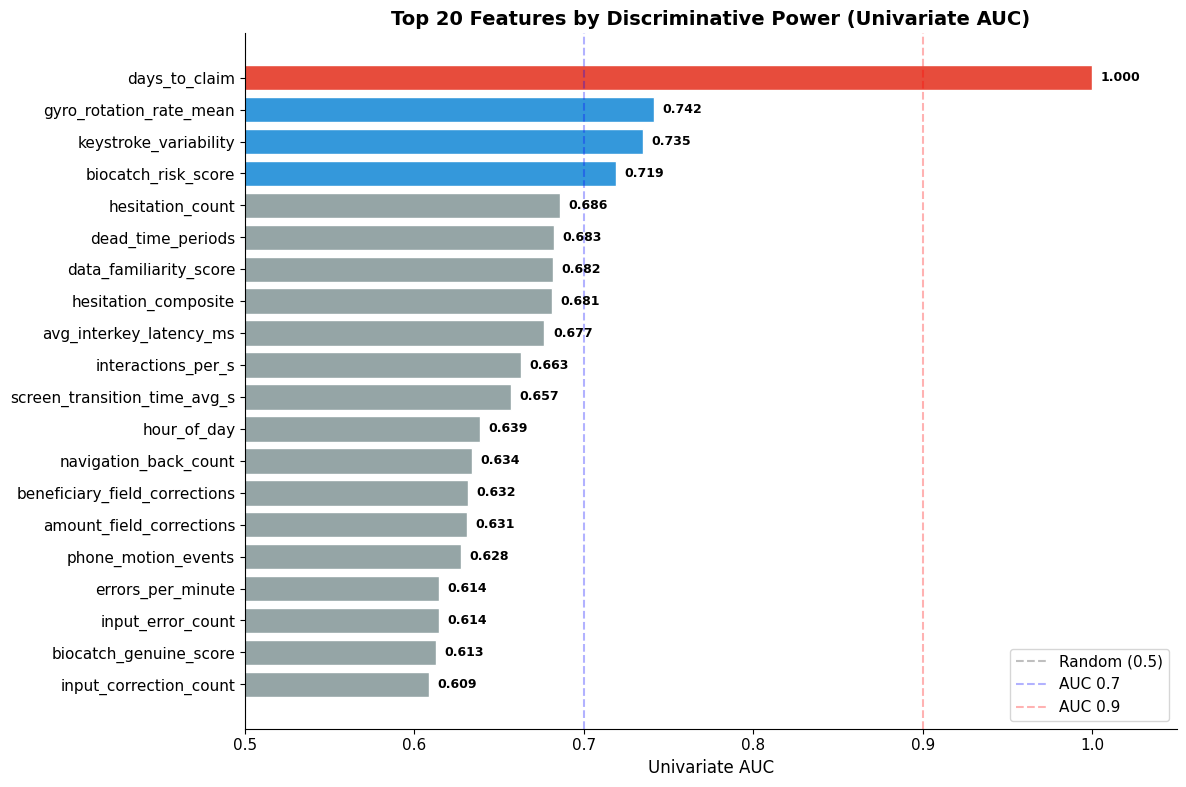

In [33]:
# 5.2 Top 20 by univariate AUC
top20 = df_stats.nlargest(20, 'auc_univariate')

fig, ax = plt.subplots(figsize=(12, 8))
colors_auc = ['#e74c3c' if x>=0.9 else '#f39c12' if x>=0.8 else '#3498db' if x>=0.7 else '#95a5a6'
              for x in top20['auc_univariate']]
bars = ax.barh(range(len(top20)), top20['auc_univariate'].values, color=colors_auc,
               edgecolor='white', linewidth=1)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'].values)
ax.set_xlabel('Univariate AUC')
ax.set_title('Top 20 Features by Discriminative Power (Univariate AUC)', fontweight='bold')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.axvline(x=0.7, color='blue', linestyle='--', alpha=0.3, label='AUC 0.7')
ax.axvline(x=0.9, color='red', linestyle='--', alpha=0.3, label='AUC 0.9')
for bar, val in zip(bars, top20['auc_univariate'].values):
    ax.text(val+0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=9, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0.5, 1.05)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

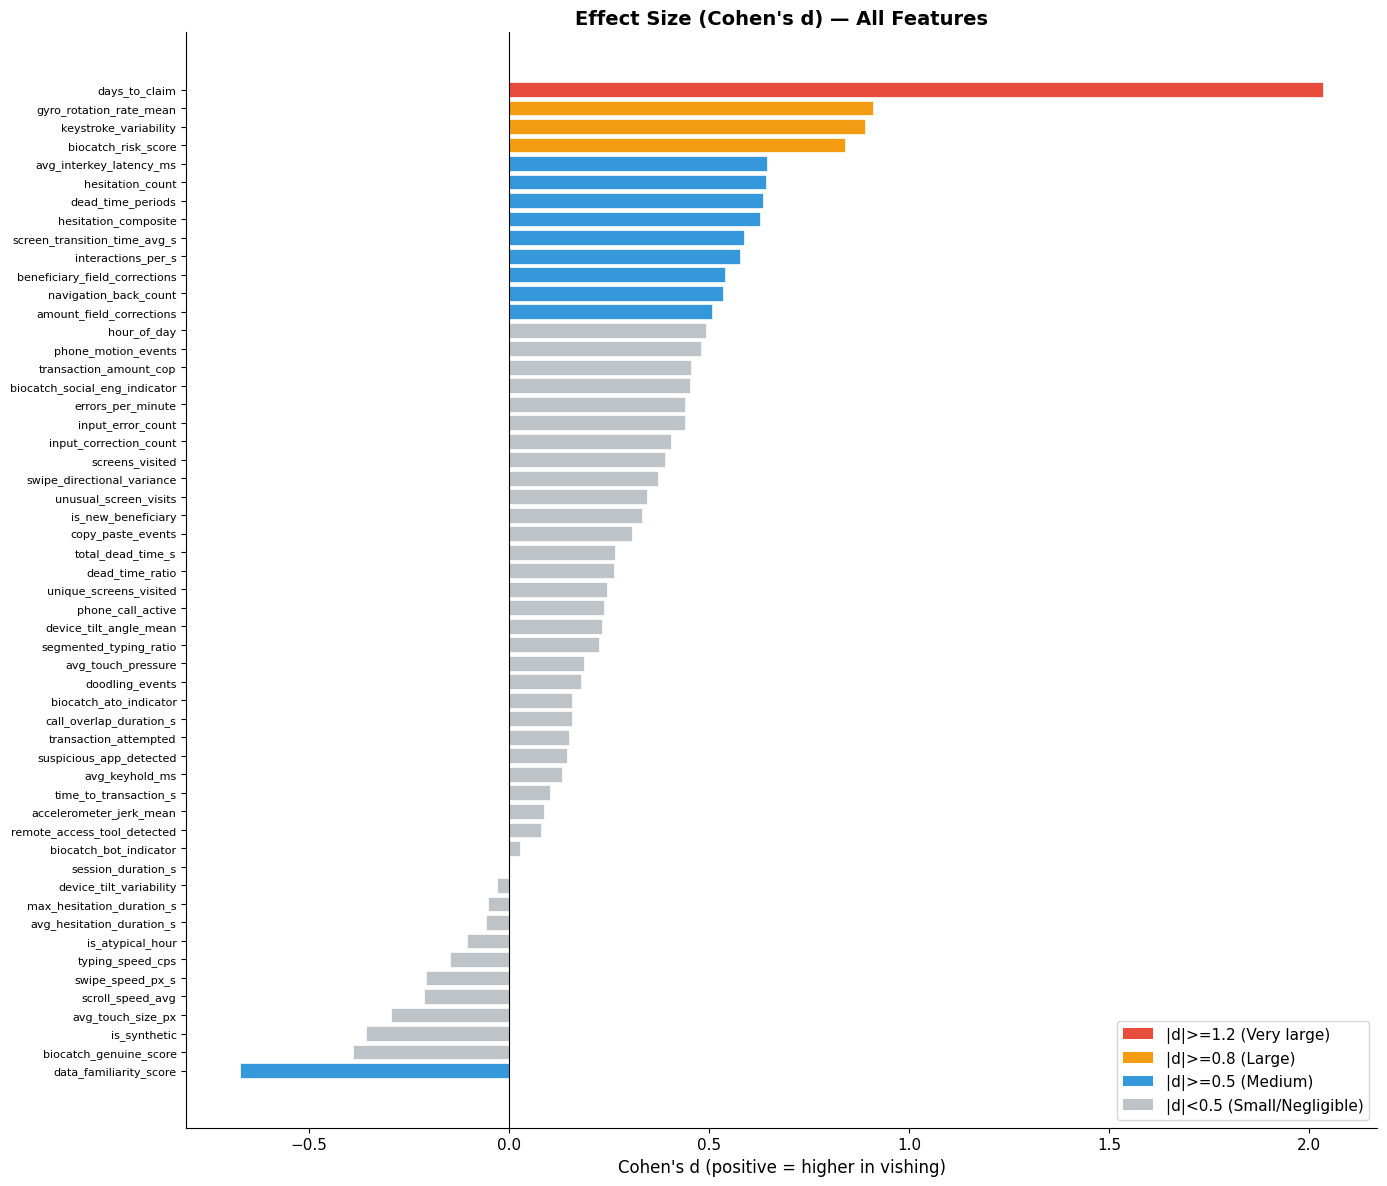

In [34]:
# 5.3 Cohen's d — all features
fig, ax = plt.subplots(figsize=(14, 12))
df_sorted = df_stats.sort_values('cohens_d')
colors_d = ['#e74c3c' if abs(d)>=1.2 else '#f39c12' if abs(d)>=0.8 else '#3498db' if abs(d)>=0.5
            else '#bdc3c7' for d in df_sorted['cohens_d']]
ax.barh(range(len(df_sorted)), df_sorted['cohens_d'].values, color=colors_d,
        edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['feature'].values, fontsize=8)
ax.set_xlabel("Cohen's d (positive = higher in vishing)")
ax.set_title("Effect Size (Cohen's d) — All Features", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.legend(handles=[
    Patch(facecolor='#e74c3c', label='|d|>=1.2 (Very large)'),
    Patch(facecolor='#f39c12', label='|d|>=0.8 (Large)'),
    Patch(facecolor='#3498db', label='|d|>=0.5 (Medium)'),
    Patch(facecolor='#bdc3c7', label='|d|<0.5 (Small/Negligible)'),
], loc='lower right')
plt.tight_layout()
plt.show()

## 6. Analysis of Binary and Categorical Variables

In [35]:
binary_features = [
    'phone_call_active', 'is_atypical_hour', 'transaction_attempted',
    'is_new_beneficiary', 'remote_access_tool_detected', 'suspicious_app_detected'
]

binary_results = []
for feat in binary_features:
    ct = pd.crosstab(df[feat], df['is_vishing'])
    chi2_stat, p, dof, expected = chi2_contingency(ct)
    try:
        a=ct.loc[1,1]; b=ct.loc[1,0]; c=ct.loc[0,1]; d_=ct.loc[0,0]
        or_ = (a*d_)/(b*c) if (b*c)>0 else np.inf
    except:
        or_ = np.nan
    binary_results.append({
        'feature': feat,
        'pct_legit': df_legit[feat].mean()*100,
        'pct_vishing': df_vishing[feat].mean()*100,
        'chi2': chi2_stat, 'p_value': p, 'odds_ratio': or_,
    })

df_binary = pd.DataFrame(binary_results).sort_values('odds_ratio', ascending=False)
print('BINARY VARIABLES — Chi-square + Odds Ratio')
print('='*80)
for _, row in df_binary.iterrows():
    sig = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else 'ns'
    print(f"  {row['feature']}: Legit={row['pct_legit']:.1f}% | Vishing={row['pct_vishing']:.1f}% | OR={row['odds_ratio']:.2f}x | {sig}")

BINARY VARIABLES — Chi-square + Odds Ratio
  is_new_beneficiary: Legit=15.8% | Vishing=29.5% | OR=2.24x | ***
  phone_call_active: Legit=29.8% | Vishing=41.0% | OR=1.63x | ***
  suspicious_app_detected: Legit=12.1% | Vishing=17.4% | OR=1.53x | ***
  transaction_attempted: Legit=56.1% | Vishing=63.4% | OR=1.36x | ***
  remote_access_tool_detected: Legit=10.8% | Vishing=13.4% | OR=1.28x | ***
  is_atypical_hour: Legit=36.8% | Vishing=32.3% | OR=0.82x | ***


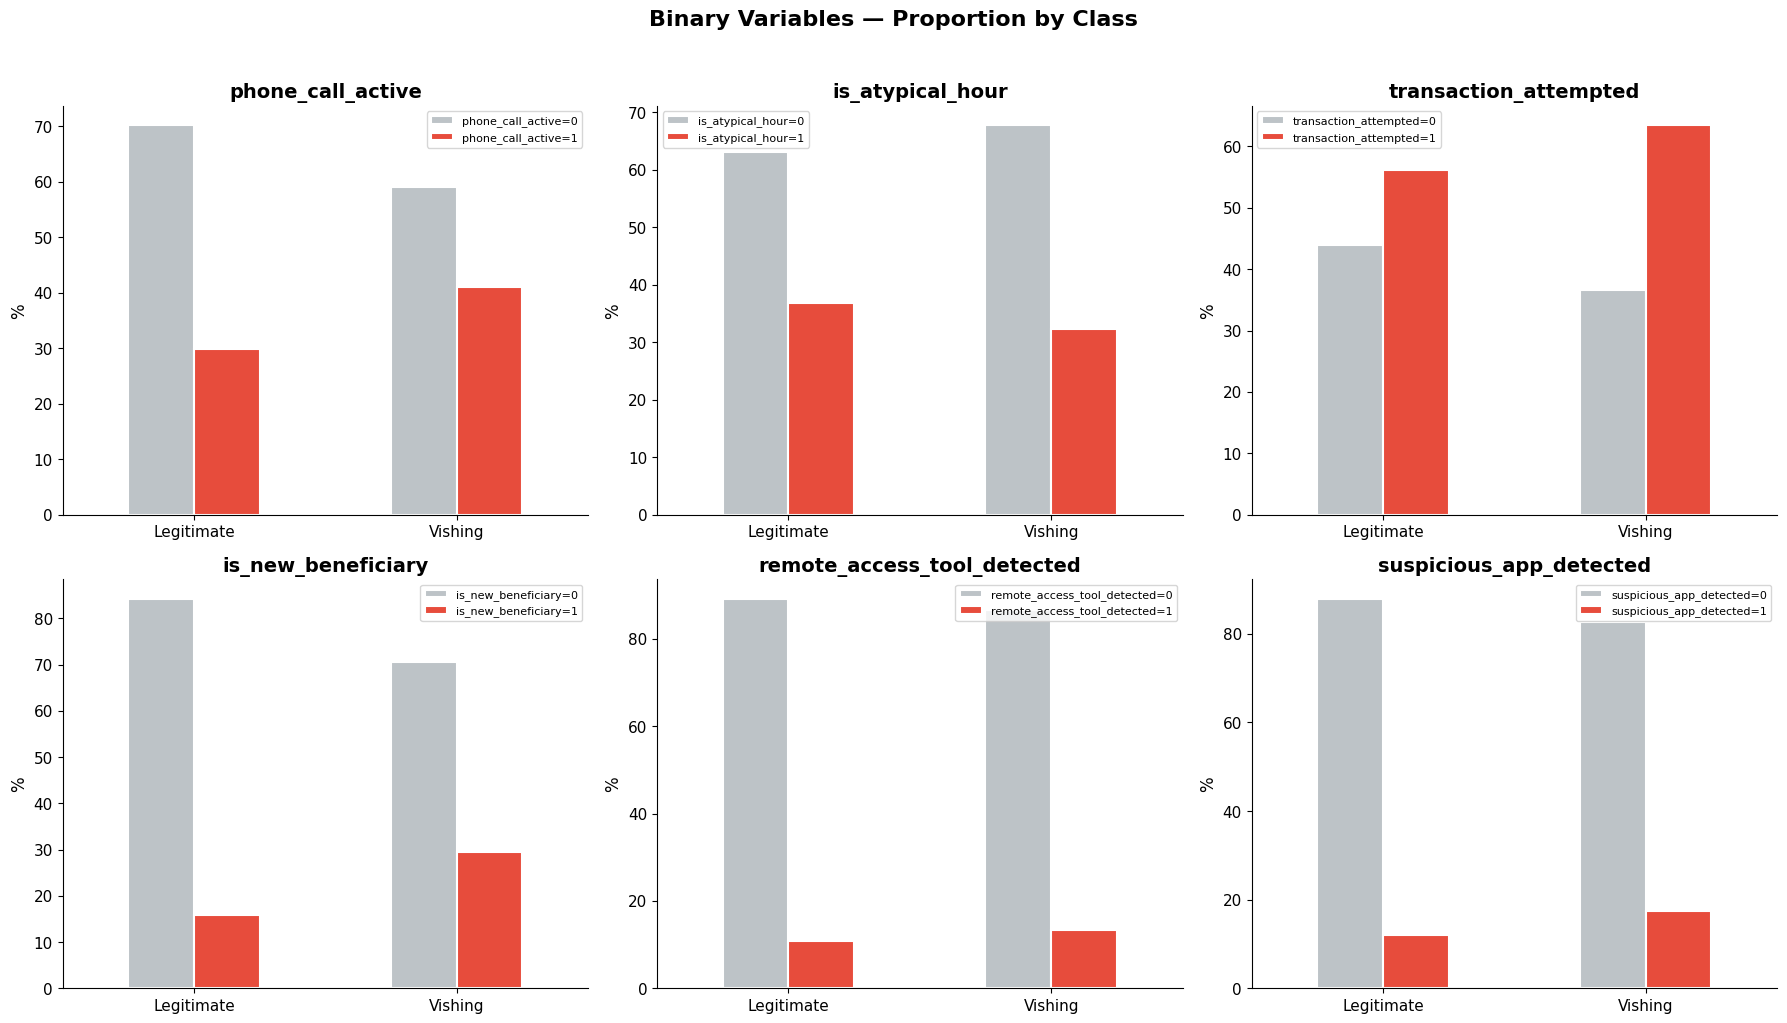

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for i, feat in enumerate(binary_features):
    ax = axes[i]
    ct = pd.crosstab(df['is_vishing'], df[feat], normalize='index') * 100
    ct.index = ['Legitimate', 'Vishing']
    ct.columns = [f'{feat}=0', f'{feat}=1']
    ct.plot(kind='bar', ax=ax, color=['#bdc3c7', COLORS['vishing']], edgecolor='white', linewidth=1.5)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(fontsize=8)
plt.suptitle('Binary Variables — Proportion by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Comparative Boxplots — Top Features

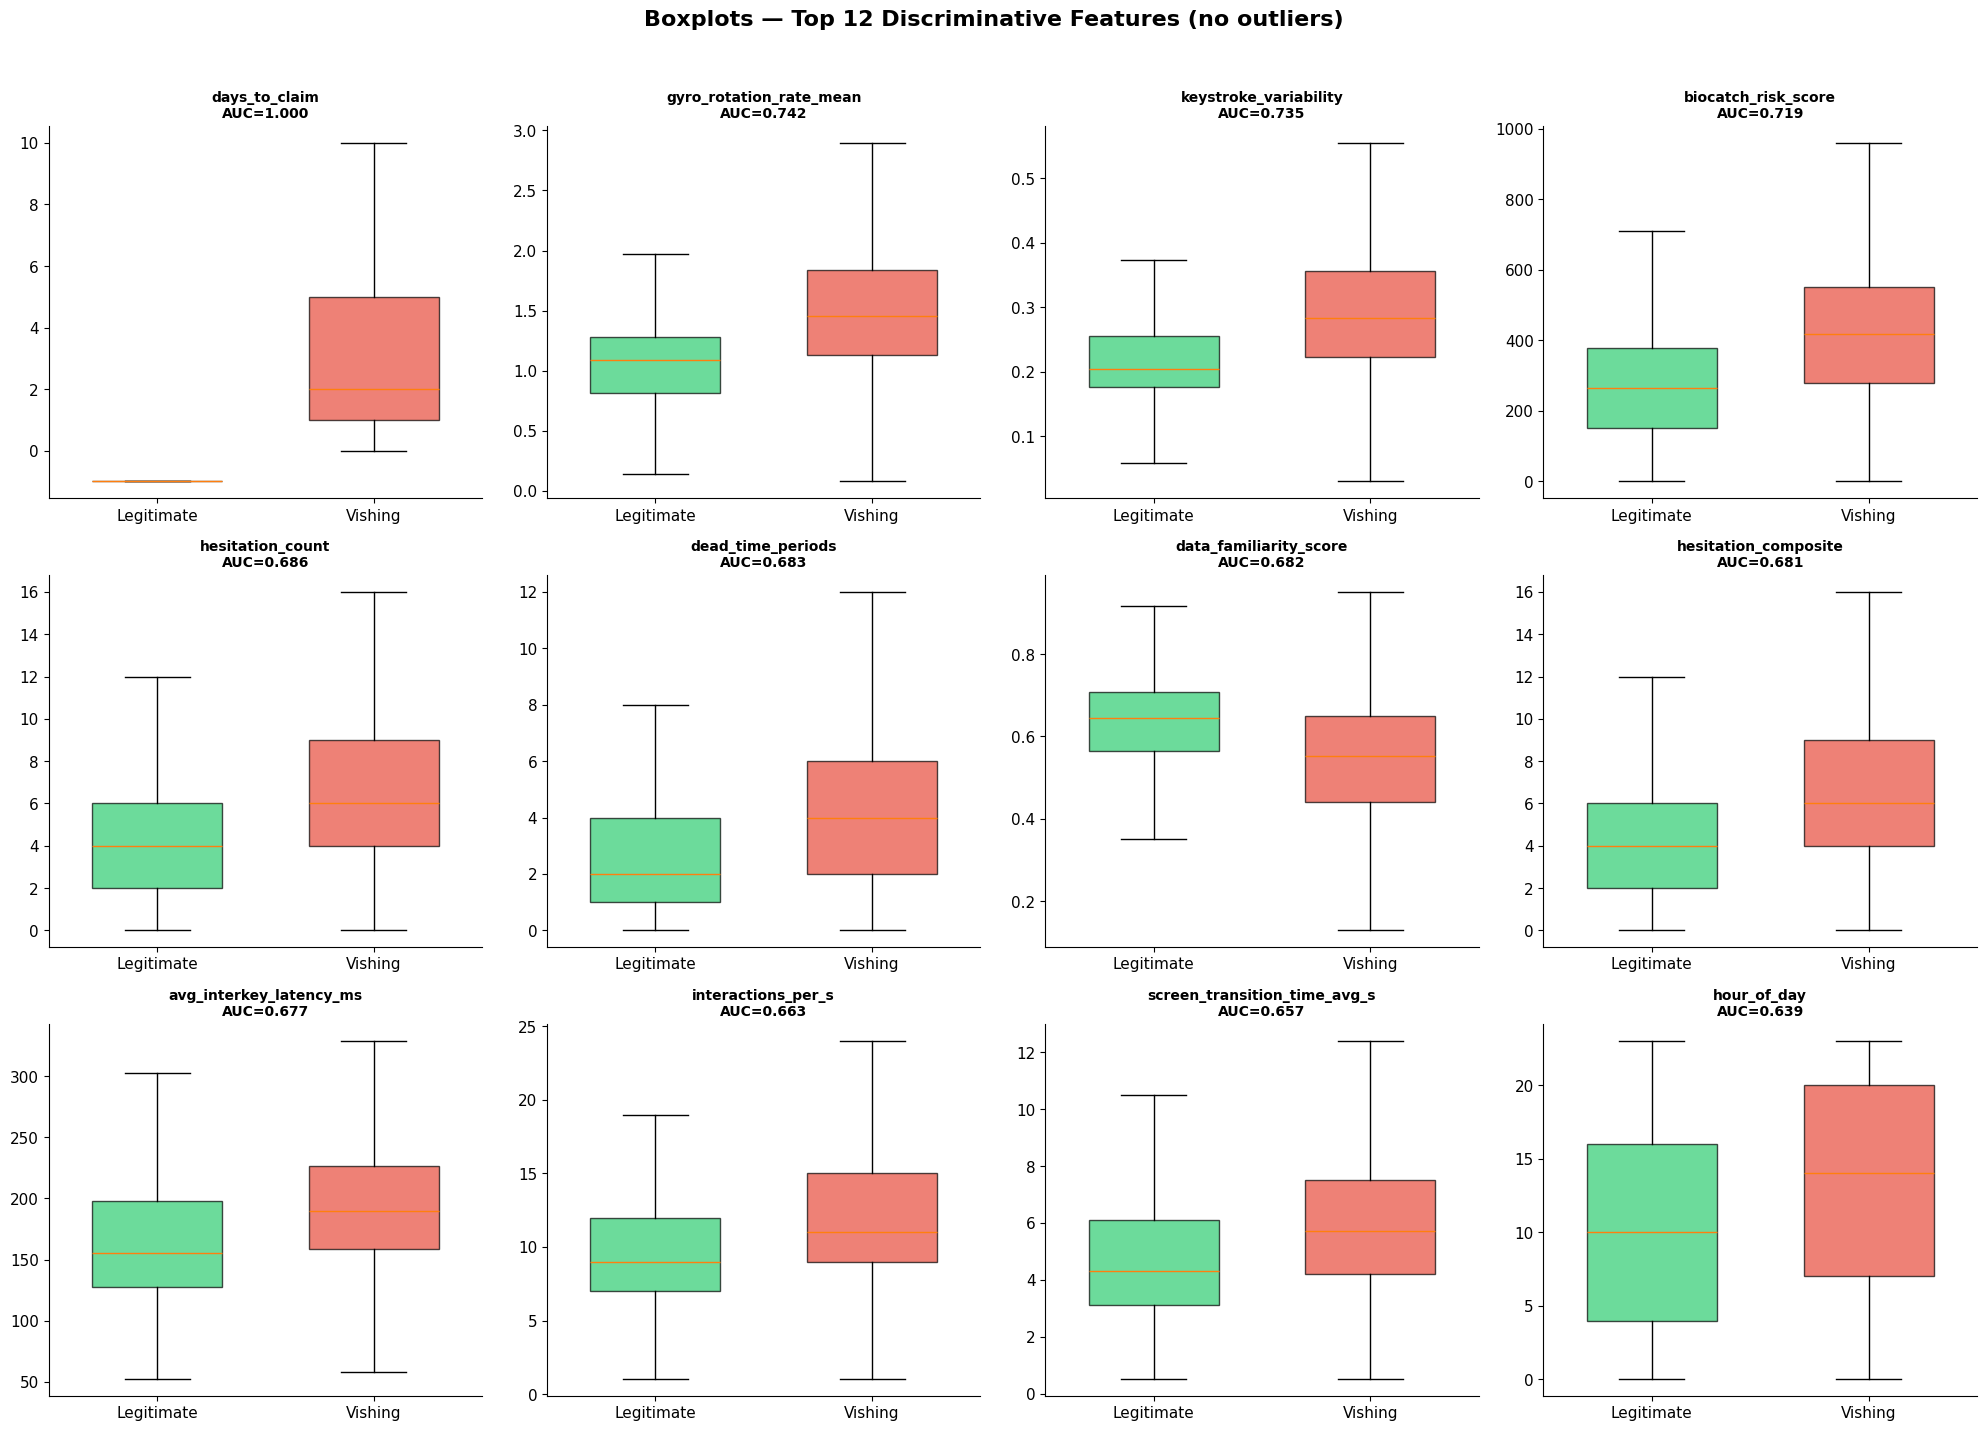

In [37]:
top12 = df_stats.nlargest(12, 'auc_univariate')['feature'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.ravel()
for i, feat in enumerate(top12):
    ax = axes[i]
    bp = ax.boxplot(
        [df_legit[feat].sample(10000, random_state=42).values, df_vishing[feat].values],
        labels=['Legitimate', 'Vishing'], patch_artist=True, widths=0.6, showfliers=False
    )
    bp['boxes'][0].set_facecolor(COLORS['legit'])
    bp['boxes'][1].set_facecolor(COLORS['vishing'])
    for box in bp['boxes']:
        box.set_alpha(0.7)
    auc_val = df_stats[df_stats['feature']==feat]['auc_univariate'].values[0]
    ax.set_title(f'{feat}\nAUC={auc_val:.3f}', fontweight='bold', fontsize=10)

plt.suptitle('Boxplots — Top 12 Discriminative Features (no outliers)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

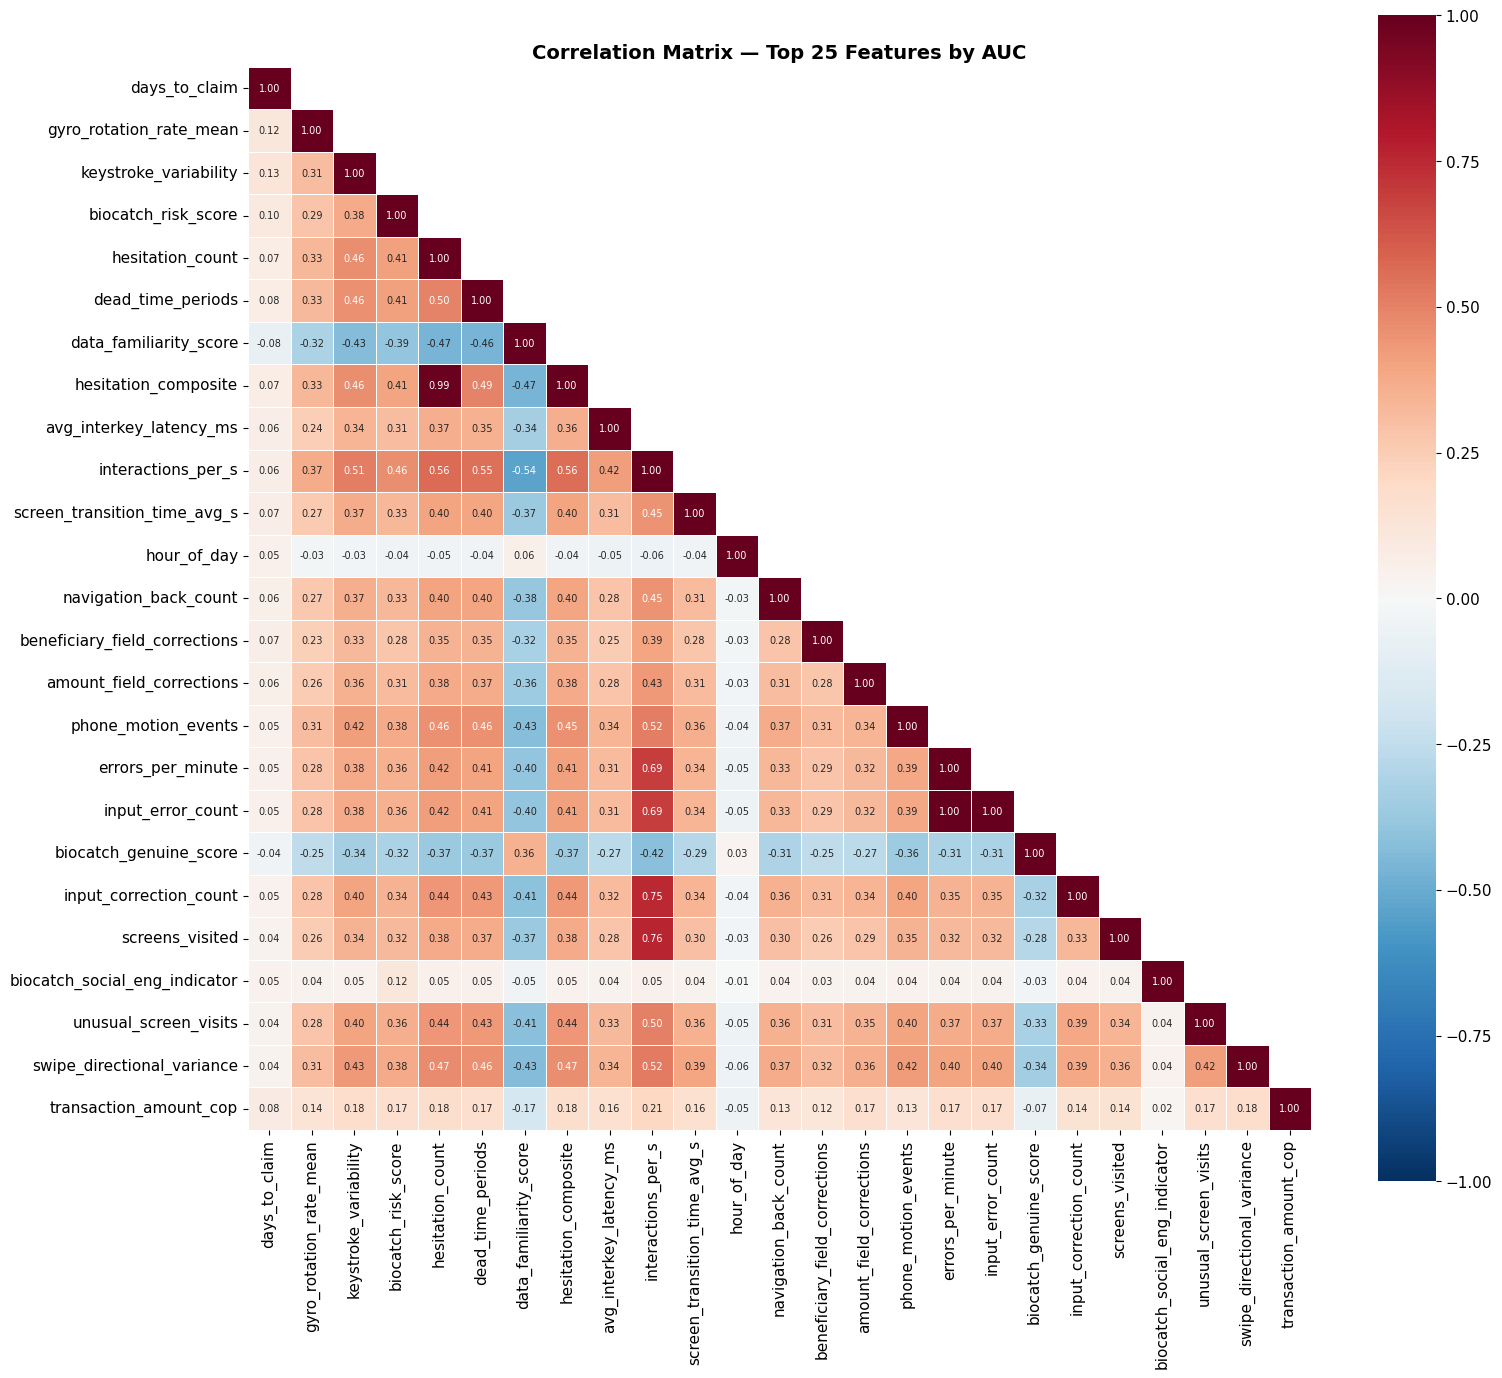

In [39]:
top25_feats = df_stats.nlargest(25, 'auc_univariate')['feature'].tolist()
corr_matrix = df[top25_feats].sample(100_000, random_state=42).corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size':7}, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Top 25 Features by AUC', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [40]:
# Highly correlated pairs (|r| > 0.7)
high_corr = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append({'feature_1': cols[i], 'feature_2': cols[j], 'correlation': r})

print(f'Pairs with |correlation| > 0.7: {len(high_corr)}')
if high_corr:
    df_hc = pd.DataFrame(high_corr)
    df_hc['abs_corr'] = df_hc['correlation'].abs()
    for _, row in df_hc.sort_values('abs_corr', ascending=False).iterrows():
        print(f"  {row['feature_1']:35s} <-> {row['feature_2']:35s}  r={row['correlation']:+.3f}")
    print('Consider removing one of each pair to avoid multicollinearity.')
else:
    print('  No pairs found with |r| > 0.7')

Pairs with |correlation| > 0.7: 4
  errors_per_minute                   <-> input_error_count                    r=+1.000
  hesitation_count                    <-> hesitation_composite                 r=+0.990
  interactions_per_s                  <-> screens_visited                      r=+0.762
  interactions_per_s                  <-> input_correction_count               r=+0.754
Consider removing one of each pair to avoid multicollinearity.


## 9. Bivariate Analysis — Scatterplots

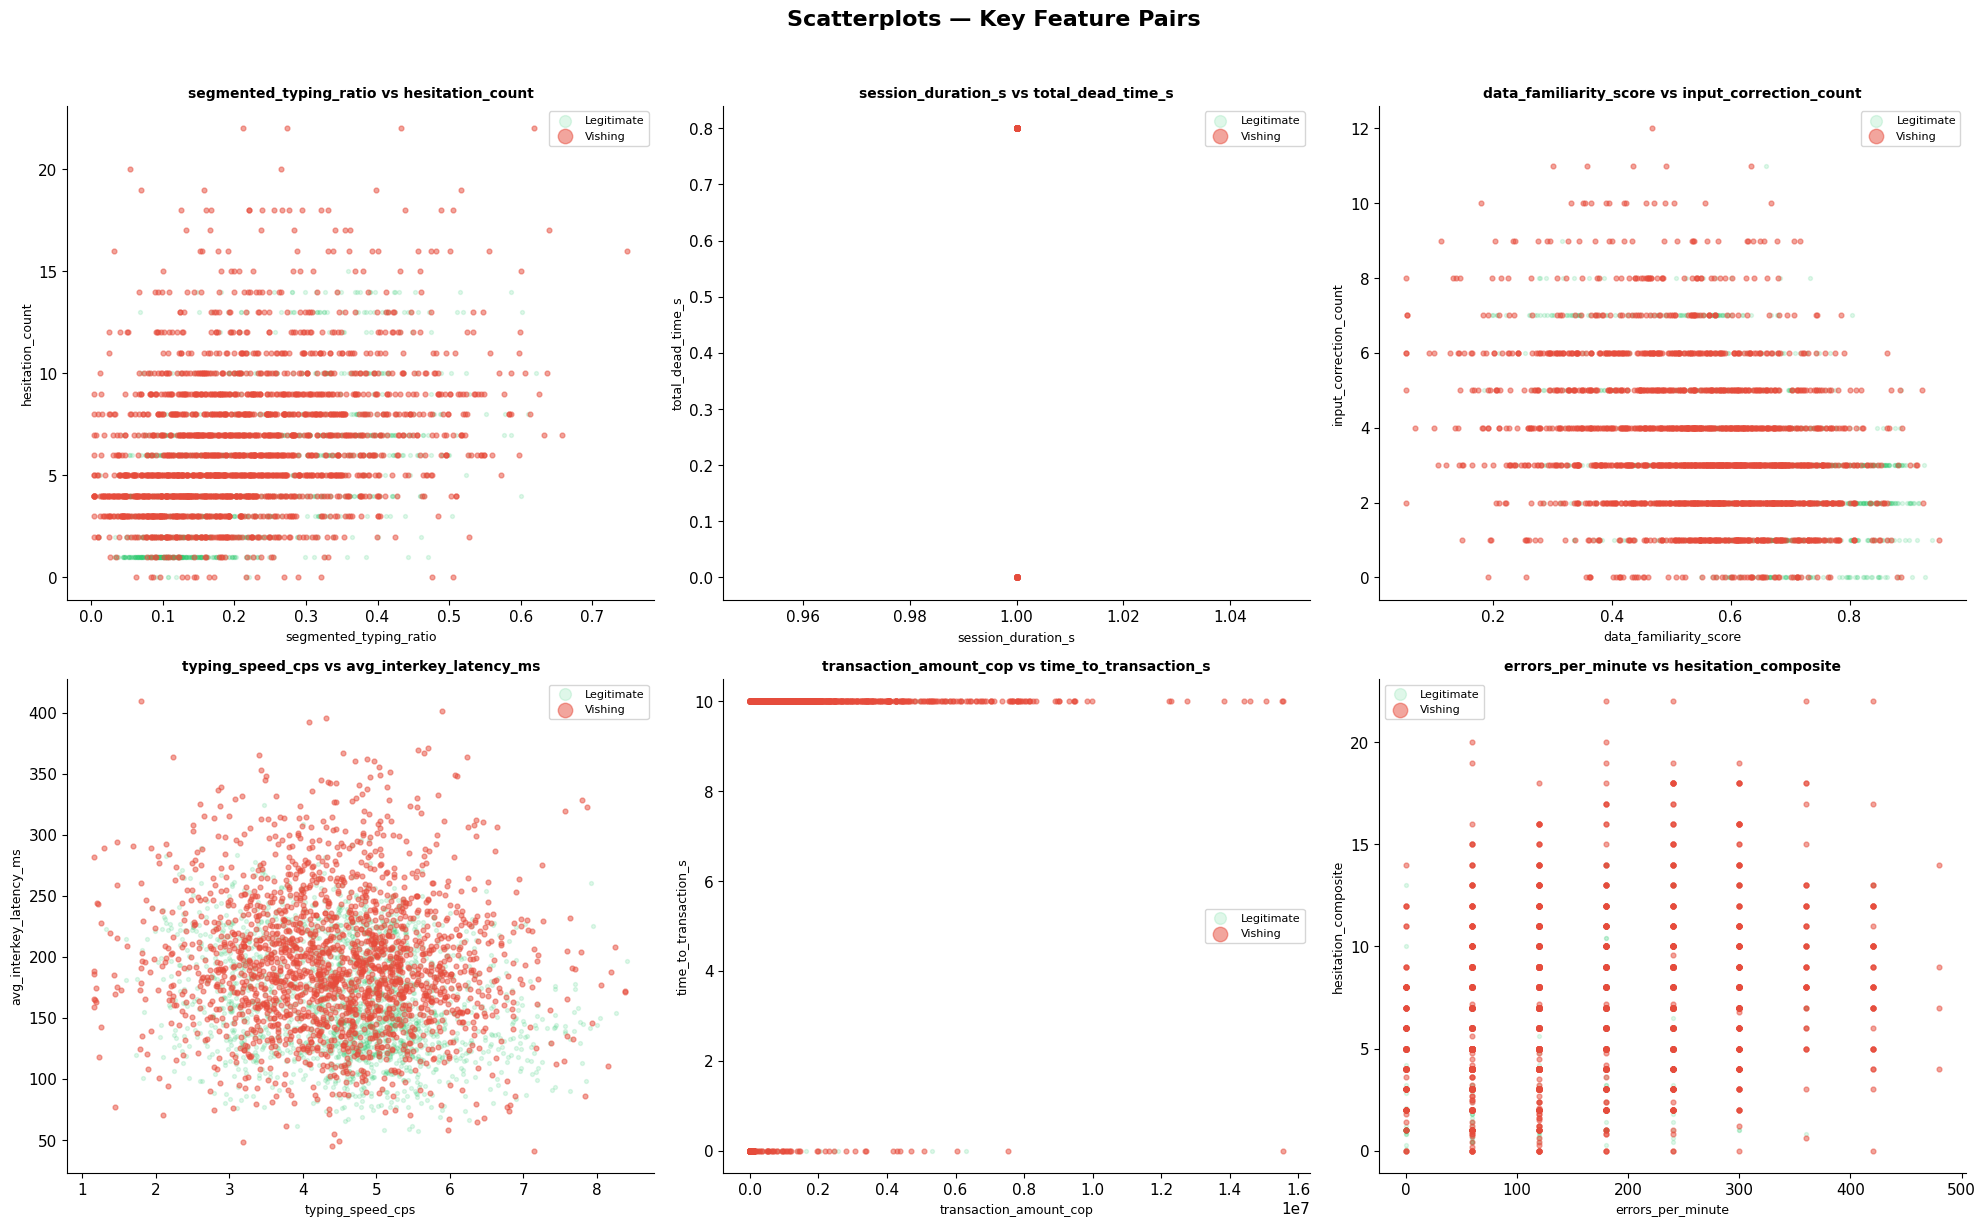

In [41]:
pairs = [
    ('segmented_typing_ratio', 'hesitation_count'),
    ('session_duration_s', 'total_dead_time_s'),
    ('data_familiarity_score', 'input_correction_count'),
    ('typing_speed_cps', 'avg_interkey_latency_ms'),
    ('transaction_amount_cop', 'time_to_transaction_s'),
    ('errors_per_minute', 'hesitation_composite'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()
for i, (xf, yf) in enumerate(pairs):
    ax = axes[i]
    ls = df_legit.sample(2000, random_state=42)
    vs = df_vishing.sample(min(2000, len(df_vishing)), random_state=42)
    ax.scatter(ls[xf], ls[yf], c=COLORS['legit'], alpha=0.15, s=8, label='Legitimate')
    ax.scatter(vs[xf], vs[yf], c=COLORS['vishing'], alpha=0.5, s=12, label='Vishing')
    ax.set_xlabel(xf, fontsize=9)
    ax.set_ylabel(yf, fontsize=9)
    ax.set_title(f'{xf} vs {yf}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8, markerscale=3)
plt.suptitle('Scatterplots — Key Feature Pairs', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Comparative Behavioral Profile

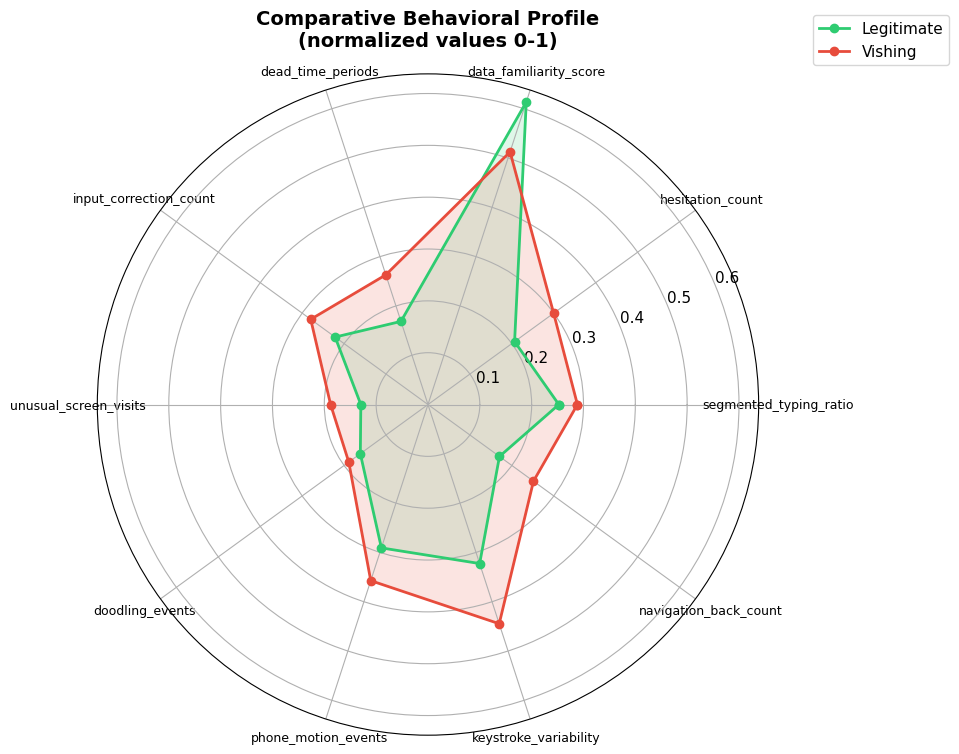

In [43]:
profile_features = [
    'segmented_typing_ratio', 'hesitation_count', 'data_familiarity_score',
    'dead_time_periods', 'input_correction_count', 'unusual_screen_visits',
    'doodling_events', 'phone_motion_events', 'keystroke_variability',
    'navigation_back_count'
]

profile_data = []
for feat in profile_features:
    gmin, gmax = df[feat].min(), df[feat].max()
    rng = gmax - gmin if gmax > gmin else 1
    profile_data.append({
        'feature': feat,
        'legit': (df_legit[feat].mean() - gmin) / rng,
        'vishing': (df_vishing[feat].mean() - gmin) / rng
    })
df_profile = pd.DataFrame(profile_data)

angles = np.linspace(0, 2*np.pi, len(profile_features), endpoint=False).tolist()
angles += angles[:1]
lv = df_profile['legit'].tolist() + [df_profile['legit'].iloc[0]]
vv = df_profile['vishing'].tolist() + [df_profile['vishing'].iloc[0]]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.plot(angles, lv, 'o-', color=COLORS['legit'], linewidth=2, label='Legitimate', markersize=6)
ax.fill(angles, lv, alpha=0.15, color=COLORS['legit'])
ax.plot(angles, vv, 'o-', color=COLORS['vishing'], linewidth=2, label='Vishing', markersize=6)
ax.fill(angles, vv, alpha=0.15, color=COLORS['vishing'])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(profile_features, fontsize=9)
ax.set_title('Comparative Behavioral Profile\n(normalized values 0-1)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

In [44]:
print('COMPARATIVE PROFILE — MEDIAN BY CLASS')
print('='*88)
print(f'{"Feature":40s} {"Legitimate":>10s} {"Vishing":>10s} {"Ratio":>8s} {"Direction":>10s}')
print('-'*88)
key_features = [
    'phone_call_active', 'segmented_typing_ratio', 'session_duration_s',
    'hesitation_count', 'avg_hesitation_duration_s', 'total_dead_time_s',
    'data_familiarity_score', 'typing_speed_cps', 'input_correction_count',
    'unusual_screen_visits', 'transaction_amount_cop', 'is_new_beneficiary',
    'doodling_events', 'phone_motion_events', 'keystroke_variability',
    'navigation_back_count', 'amount_field_corrections', 'beneficiary_field_corrections',
    'errors_per_minute', 'interactions_per_s', 'hesitation_composite',
]
for feat in key_features:
    ml = df_legit[feat].median()
    mv = df_vishing[feat].median()
    ratio = mv/ml if ml != 0 else float('inf')
    direction = 'HIGHER' if mv>ml else 'LOWER' if mv<ml else 'EQUAL'
    print(f'{feat:40s} {ml:10.2f} {mv:10.2f} {ratio:8.2f}x {direction:>10s}')

COMPARATIVE PROFILE — MEDIAN BY CLASS
Feature                                  Legitimate    Vishing    Ratio  Direction
----------------------------------------------------------------------------------------
phone_call_active                              0.00       0.00      infx      EQUAL
segmented_typing_ratio                         0.16       0.20     1.25x     HIGHER
session_duration_s                             1.00       1.00     1.00x      EQUAL
hesitation_count                               4.00       6.00     1.50x     HIGHER
avg_hesitation_duration_s                      1.00       1.00     1.00x      EQUAL
total_dead_time_s                              0.80       0.80     1.00x      EQUAL
data_familiarity_score                         0.65       0.55     0.86x      LOWER
typing_speed_cps                               4.76       4.51     0.95x      LOWER
input_correction_count                         3.00       3.00     1.00x      EQUAL
unusual_screen_visits             

## 11. Transaction Analysis

Sessions with a transaction: 562,361 (56.2%)
  Legitimate: 552,845 (56.1%)
  Vishing:    9,516 (63.4%)


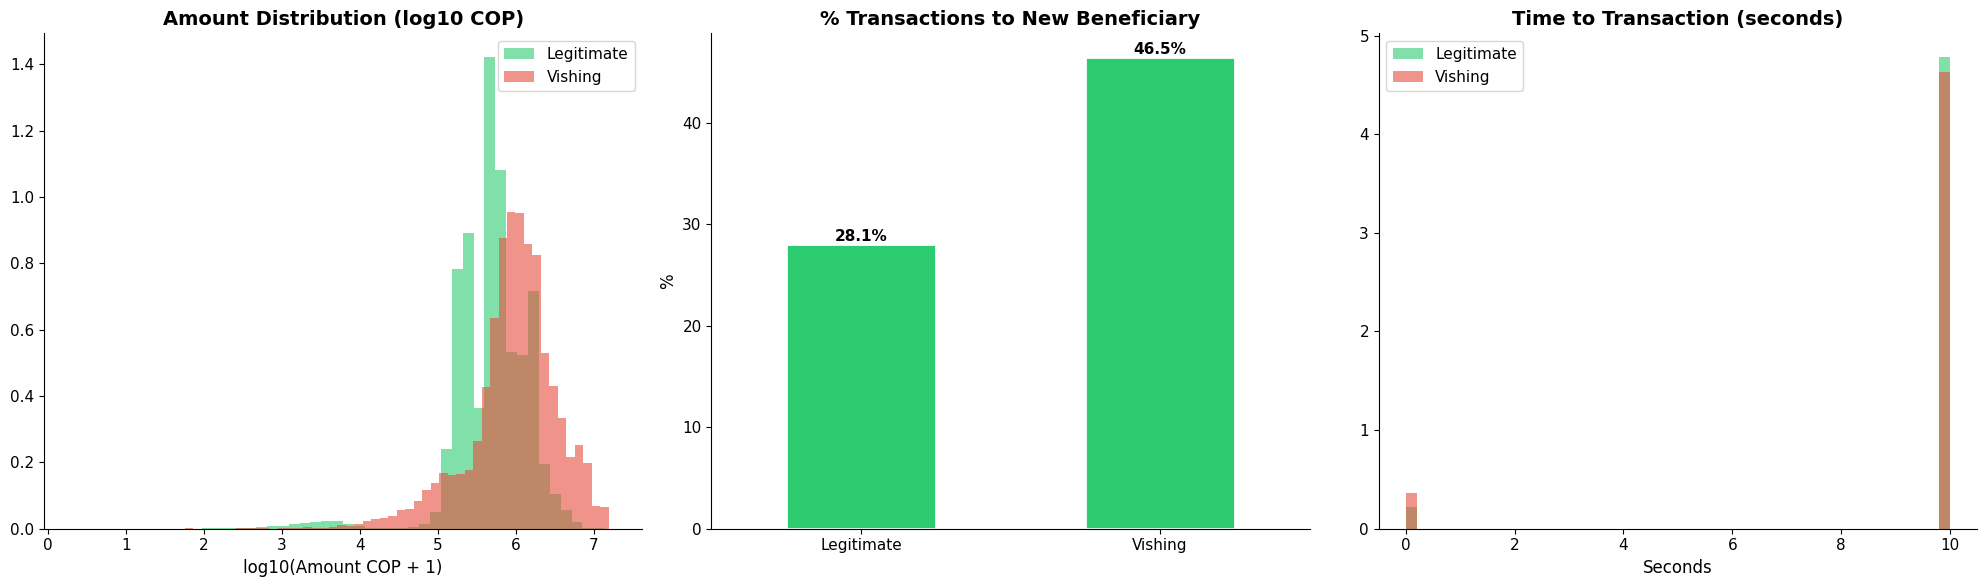

In [45]:
df_tx = df[df['transaction_attempted']==1].copy()
df_tx_l = df_tx[df_tx['is_vishing']==0]
df_tx_v = df_tx[df_tx['is_vishing']==1]

print(f'Sessions with a transaction: {len(df_tx):,} ({len(df_tx)/len(df)*100:.1f}%)')
print(f'  Legitimate: {len(df_tx_l):,} ({len(df_tx_l)/len(df_legit)*100:.1f}%)')
print(f'  Vishing:    {len(df_tx_v):,} ({len(df_tx_v)/len(df_vishing)*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for subset, color, label in [(df_tx_l, COLORS['legit'], 'Legitimate'), (df_tx_v, COLORS['vishing'], 'Vishing')]:
    amounts = subset['transaction_amount_cop']
    amounts = amounts[amounts > 0]
    if len(amounts) > 0:
        axes[0].hist(np.log10(amounts+1), bins=50, alpha=0.6, color=color, label=label, density=True, edgecolor='none')
axes[0].set_title('Amount Distribution (log10 COP)', fontweight='bold')
axes[0].set_xlabel('log10(Amount COP + 1)')
axes[0].legend()

new_ben = pd.DataFrame({'Legitimate':[df_tx_l['is_new_beneficiary'].mean()*100],
                         'Vishing':[df_tx_v['is_new_beneficiary'].mean()*100]}).T
new_ben.columns = ['%']
new_ben.plot(kind='bar', ax=axes[1], color=[COLORS['legit'], COLORS['vishing']],
             edgecolor='white', linewidth=2, legend=False)
axes[1].set_title('% Transactions to New Beneficiary', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

for subset, color, label in [(df_tx_l, COLORS['legit'], 'Legitimate'), (df_tx_v, COLORS['vishing'], 'Vishing')]:
    axes[2].hist(subset['time_to_transaction_s'], bins=50, alpha=0.6, color=color,
                 label=label, density=True, edgecolor='none')
axes[2].set_title('Time to Transaction (seconds)', fontweight='bold')
axes[2].set_xlabel('Seconds')
axes[2].legend()

plt.tight_layout()
plt.show()

## 12. Principal Component Analysis (PCA)

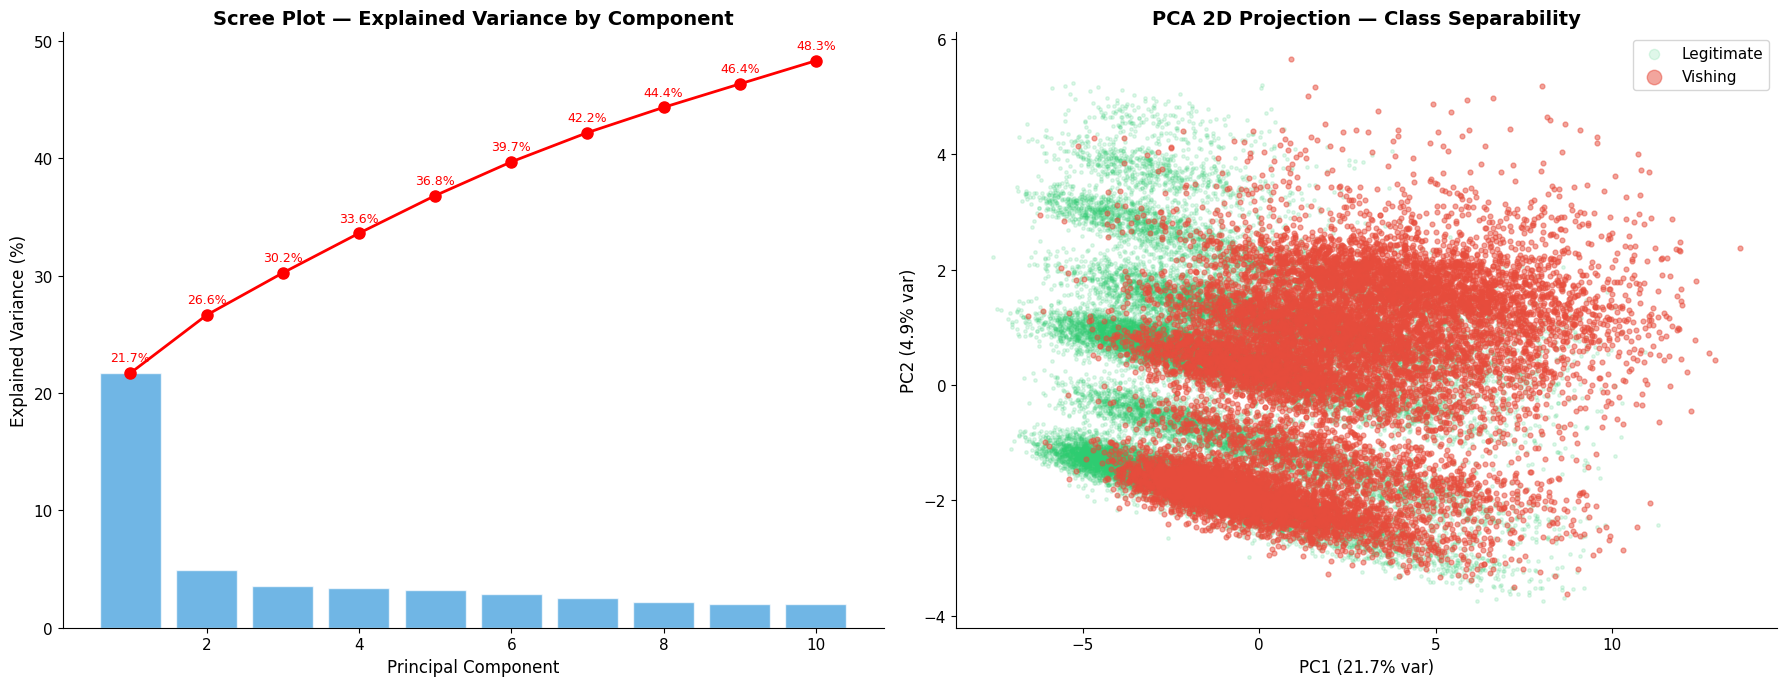

Cumulative variance with 5 components:  36.8%
Cumulative variance with 10 components: 48.3%


In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = [c for c in numeric_cols if c not in ['is_vishing', 'hour_of_day']]

df_pca_sample = pd.concat([
    df_legit.sample(30000, random_state=42), df_vishing
]).reset_index(drop=True)

X = df_pca_sample[pca_features].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

axes[0].bar(range(1, 11), explained, color=COLORS['neutral'], edgecolor='white', alpha=0.7)
axes[0].plot(range(1, 11), cumulative, 'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Explained Variance by Component', fontweight='bold')
for i, (e, c) in enumerate(zip(explained, cumulative)):
    axes[0].text(i+1, c+1, f'{c:.1f}%', ha='center', fontsize=9, color='red')

y_pca = df_pca_sample['is_vishing'].values
axes[1].scatter(X_pca[y_pca==0, 0], X_pca[y_pca==0, 1], c=COLORS['legit'], alpha=0.15, s=6, label='Legitimate')
axes[1].scatter(X_pca[y_pca==1, 0], X_pca[y_pca==1, 1], c=COLORS['vishing'], alpha=0.5, s=12, label='Vishing')
axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1f}% var)')
axes[1].set_title('PCA 2D Projection — Class Separability', fontweight='bold')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()
print(f'Cumulative variance with 5 components:  {cumulative[4]:.1f}%')
print(f'Cumulative variance with 10 components: {cumulative[9]:.1f}%')

In [47]:
loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1','PC2'], index=pca_features)
loadings['PC1_abs'] = loadings['PC1'].abs()
loadings['PC2_abs'] = loadings['PC2'].abs()
print('TOP 10 FEATURES BY LOADING ON PC1:')
print(loadings.nlargest(10,'PC1_abs')[['PC1']].to_string())
print('\nTOP 10 FEATURES BY LOADING ON PC2:')
print(loadings.nlargest(10,'PC2_abs')[['PC2']].to_string())

TOP 10 FEATURES BY LOADING ON PC1:
                             PC1
interactions_per_s      0.253664
hesitation_count        0.216846
hesitation_composite    0.215647
dead_time_periods       0.207221
segmented_typing_ratio  0.204236
keystroke_variability   0.197930
data_familiarity_score -0.197790
input_error_count       0.195316
errors_per_minute       0.195316
biocatch_risk_score     0.191644

TOP 10 FEATURES BY LOADING ON PC2:
                              PC2
time_to_transaction_s    0.505104
transaction_attempted    0.499993
is_new_beneficiary       0.323183
dead_time_ratio         -0.274498
total_dead_time_s       -0.274396
transaction_amount_cop   0.274252
call_overlap_duration_s  0.207532
phone_call_active        0.203161
avg_keyhold_ms          -0.117962
accelerometer_jerk_mean -0.104507


## 13. Outlier Detection

In [48]:
outlier_features = [
    'session_duration_s', 'transaction_amount_cop', 'hesitation_count',
    'total_dead_time_s', 'typing_speed_cps', 'errors_per_minute',
    'interactions_per_s', 'hesitation_composite'
]

print('OUTLIER ANALYSIS (IQR, threshold 1.5xIQR)')
print('='*80)
for feat in outlier_features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    out = df[(df[feat] < lo) | (df[feat] > hi)]
    n = len(out)
    pct_v = out['is_vishing'].mean()*100 if n > 0 else 0
    print(f'\n  {feat}:')
    print(f'    IQR: [{Q1:.2f}, {Q3:.2f}], bounds: [{lo:.2f}, {hi:.2f}]')
    print(f'    Outliers: {n:,} ({n/len(df)*100:.2f}%)')
    print(f'    % vishing among outliers: {pct_v:.1f}% (vs {df["is_vishing"].mean()*100:.1f}% global)')

OUTLIER ANALYSIS (IQR, threshold 1.5xIQR)

  session_duration_s:
    IQR: [1.00, 1.00], bounds: [1.00, 1.00]
    Outliers: 0 (0.00%)
    % vishing among outliers: 0.0% (vs 1.5% global)

  transaction_amount_cop:
    IQR: [0.00, 548450.50], bounds: [-822675.75, 1371126.25]
    Outliers: 90,785 (9.08%)
    % vishing among outliers: 3.9% (vs 1.5% global)

  hesitation_count:
    IQR: [2.00, 6.00], bounds: [-4.00, 12.00]
    Outliers: 29,488 (2.95%)
    % vishing among outliers: 2.8% (vs 1.5% global)

  total_dead_time_s:
    IQR: [0.80, 0.80], bounds: [0.80, 0.80]
    Outliers: 93,326 (9.33%)
    % vishing among outliers: 0.5% (vs 1.5% global)

  typing_speed_cps:
    IQR: [3.99, 5.32], bounds: [1.99, 7.32]
    Outliers: 21,708 (2.17%)
    % vishing among outliers: 2.6% (vs 1.5% global)

  errors_per_minute:
    IQR: [60.00, 180.00], bounds: [-120.00, 360.00]
    Outliers: 2,289 (0.23%)
    % vishing among outliers: 12.9% (vs 1.5% global)

  interactions_per_s:
    IQR: [7.00, 12.00], bou

## 14. Preliminary Feature Importance (Random Forest with subsampling)

With 1M rows, a stratified subsample of 140K legitimate + all vishing is used.

Training RF on 155,000 rows (15,000 vishing, 140,000 legitimate)...
RF — 5-fold CV AUC: 1.0000 +/- 0.0000


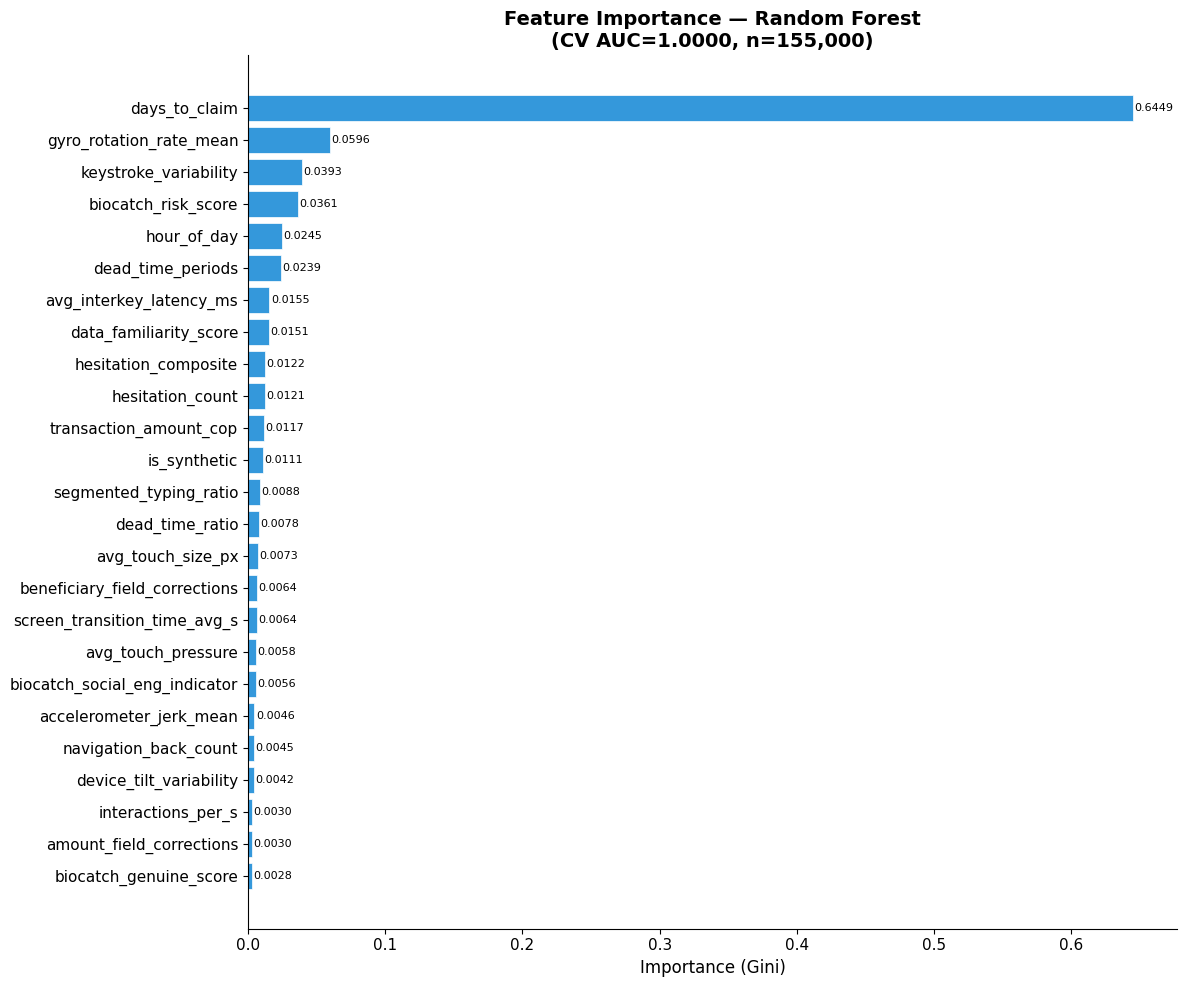

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model_features = [c for c in numeric_cols if c != 'is_vishing']

df_rf = pd.concat([
    df_legit.sample(140_000, random_state=42), df_vishing
]).sample(frac=1, random_state=42).reset_index(drop=True)

X_rf = df_rf[model_features].fillna(0).values
y_rf = df_rf['is_vishing'].values

print(f'Training RF on {len(df_rf):,} rows ({y_rf.sum():,} vishing, {(y_rf==0).sum():,} legitimate)...')

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_rf, y_rf)
cv_scores = cross_val_score(rf, X_rf, y_rf, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'RF — 5-fold CV AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

fi = pd.DataFrame({'feature': model_features, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_fi = fi.head(25)
ax.barh(range(len(top_fi)), top_fi['importance'].values, color=COLORS['neutral'],
        edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_fi)))
ax.set_yticklabels(top_fi['feature'].values)
ax.set_xlabel('Importance (Gini)')
ax.set_title(f'Feature Importance — Random Forest\n(CV AUC={cv_scores.mean():.4f}, n={len(df_rf):,})', fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(top_fi['importance'].values):
    ax.text(v+0.001, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 15. Augmentation Validation — Comparison vs Original Dataset

We verify that augmentation preserves the original statistical properties and that the discriminative signals between classes are maintained.

In [ ]:
try:
    df_orig = pd.read_csv('raw_data/biocatch_sinthetic_data.csv')
    df_orig_legit = df_orig[df_orig['is_vishing']==0]
    df_orig_vishing = df_orig[df_orig['is_vishing']==1]
    ORIG_LOADED = True
    print(f'Original dataset: {df_orig.shape[0]:,} rows x {df_orig.shape[1]} columns')
except FileNotFoundError:
    ORIG_LOADED = False
    print('Original dataset not found. Skipping comparison.')

In [ ]:
if ORIG_LOADED:
    compare_features = [
        'avg_keyhold_ms', 'typing_speed_cps', 'segmented_typing_ratio',
        'hesitation_count', 'total_dead_time_s', 'data_familiarity_score',
        'session_duration_s', 'input_correction_count', 'unusual_screen_visits',
        'transaction_amount_cop'
    ]

    aug_sample_vis = df.sample(50000, random_state=42)

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.ravel()
    for i, feat in enumerate(compare_features):
        ax = axes[i]
        ax.hist(df_orig[feat], bins=50, alpha=0.5, color='#95a5a6',
                label='Original (50K)', density=True, edgecolor='none')
        ax.hist(aug_sample_vis[feat], bins=50, alpha=0.6, color=COLORS['aug'],
                label='Augmented (1M)', density=True, edgecolor='none')
        ax.axvline(df_orig[feat].mean(), color='#7f8c8d', linestyle='--', linewidth=1.5)
        ax.axvline(df[feat].mean(), color=COLORS['aug'], linestyle='--', linewidth=1.5)
        ax.set_title(feat, fontweight='bold', fontsize=9)
        ax.legend(fontsize=7)
    fig.suptitle('Distribution Comparison: Original vs Augmented',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
if ORIG_LOADED:
    aug_ks = df.sample(50000, random_state=42)
    ks_results = []
    for feat in compare_features:
        stat, p = ks_2samp(df_orig[feat].dropna(), aug_ks[feat].dropna())
        ks_results.append({
            'feature': feat,
            'mean_orig': df_orig[feat].mean(), 'mean_aug': df[feat].mean(),
            'std_orig': df_orig[feat].std(), 'std_aug': df[feat].std(),
            'ks_stat': stat, 'ks_p': p,
        })
    df_ks = pd.DataFrame(ks_results).sort_values('ks_stat')

    print('KOLMOGOROV-SMIRNOV TEST — Original vs Augmented')
    print('(KS stat ~ 0 = similar; > 0.1 = possible drift)')
    print('='*88)
    print(f'{"Feature":35s} {"mu orig":>8s} {"mu aug":>8s} {"sigma orig":>10s} {"sigma aug":>10s} {"KS":>6s}')
    print('-'*88)
    for _, r in df_ks.iterrows():
        flag = ' <DRIFT' if r['ks_stat'] > 0.1 else ''
        print(f"{r['feature']:35s} {r['mean_orig']:8.3f} {r['mean_aug']:8.3f} {r['std_orig']:10.3f} {r['std_aug']:10.3f} {r['ks_stat']:6.4f}{flag}")
    print(f'\nMean KS: {df_ks["ks_stat"].mean():.4f}  |  Features with KS>0.1: {(df_ks["ks_stat"]>0.1).sum()}')

In [ ]:
if ORIG_LOADED:
    # Top 10 features by KS stat
    top10_ks = df_ks.nlargest(10, 'ks_stat')
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors_ks = ['#e74c3c' if x > 0.1 else '#f39c12' if x > 0.05 else '#3498db' 
                 for x in top10_ks['ks_stat']]
    
    bars = ax.barh(range(len(top10_ks)), top10_ks['ks_stat'].values, 
                    color=colors_ks, edgecolor='white', linewidth=1.5)
    
    ax.set_yticks(range(len(top10_ks)))
    ax.set_yticklabels(top10_ks['feature'].values)
    ax.set_xlabel('Kolmogorov-Smirnov Statistic', fontweight='bold')
    ax.set_title('Top 10 Features — Largest Divergence between Original and Augmented\n(KS Test)', 
                 fontweight='bold', fontsize=14)
    
    # Reference lines for drift
    ax.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Drift threshold (0.1)')
    ax.axvline(x=0.05, color='orange', linestyle='--', alpha=0.5, linewidth=2, label='Moderate threshold (0.05)')
    
    # Values on the bars
    for bar, val, p_val in zip(bars, top10_ks['ks_stat'].values, top10_ks['ks_p'].values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}\n(p={p_val:.2e})', 
                va='center', fontsize=8, fontweight='bold')
    
    ax.invert_yaxis()
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
if ORIG_LOADED:
    orig_stats = []
    for feat in compare_features:
        x0 = df_orig_legit[feat].dropna()
        x1 = df_orig_vishing[feat].dropna()
        ps = np.sqrt((x0.std()**2 + x1.std()**2)/2)
        d = (x1.mean()-x0.mean())/ps if ps > 0 else 0
        try:
            auc = roc_auc_score(df_orig['is_vishing'], df_orig[feat])
            auc = max(auc, 1-auc)
        except:
            auc = 0.5
        orig_stats.append({'feature': feat, 'cohens_d_orig': d, 'auc_orig': auc})

    df_orig_stats = pd.DataFrame(orig_stats)
    df_aug_row = df_stats[df_stats['feature'].isin(compare_features)][['feature','cohens_d','auc_univariate']]
    df_cmp = df_orig_stats.merge(df_aug_row, on='feature')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    xp = range(len(df_cmp))

    axes[0].bar([x-0.2 for x in xp], df_cmp['cohens_d_orig'].abs(), 0.4, label='Original', color='#95a5a6', alpha=0.8)
    axes[0].bar([x+0.2 for x in xp], df_cmp['cohens_d'].abs(), 0.4, label='Augmented', color=COLORS['aug'], alpha=0.8)
    axes[0].set_xticks(list(xp))
    axes[0].set_xticklabels(df_cmp['feature'], rotation=45, ha='right', fontsize=8)
    axes[0].set_ylabel("|Cohen's d|")
    axes[0].set_title("|Cohen's d| — Original vs Augmented", fontweight='bold')
    axes[0].legend()

    axes[1].bar([x-0.2 for x in xp], df_cmp['auc_orig'], 0.4, label='Original', color='#95a5a6', alpha=0.8)
    axes[1].bar([x+0.2 for x in xp], df_cmp['auc_univariate'], 0.4, label='Augmented', color=COLORS['aug'], alpha=0.8)
    axes[1].set_xticks(list(xp))
    axes[1].set_xticklabels(df_cmp['feature'], rotation=45, ha='right', fontsize=8)
    axes[1].set_ylabel('Univariate AUC')
    axes[1].set_title('Univariate AUC — Original vs Augmented', fontweight='bold')
    axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[1].legend()

    plt.suptitle('Preservation of Discriminative Signals Post-Augmentation', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    df_cmp['d_delta'] = df_cmp['cohens_d'] - df_cmp['cohens_d_orig']
    df_cmp['auc_delta'] = df_cmp['auc_univariate'] - df_cmp['auc_orig']
    print('Metric deltas (Augmented - Original):')
    print(df_cmp[['feature','d_delta','auc_delta']].to_string(index=False))